# SegmentIG0.1 soft metrics for patch success

Минимальный ноутбук для расчёта и сравнения новых soft-вариантов `delta_energy_in_importance_top` только для `SegmentIG[0;0.1]`.


## Настройка и кеш атаки

Инициализируем эксперимент и загружаем или строим кеш атак, который нужен для расчёта success/fail метрик.


In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd
from IPython.display import Image, display

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    load_segmentig_success_failure_rows,
    make_coco_people_patch_success_experiment,
    resolve_existing_path,
)

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment()
print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
cache = exp.build_or_load_cache(force=False)


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl


## Расчёт SegmentIG-only метрик

`run_segmentig_success_failure_metrics()` считает только метрики на основе `SegmentIG[0;0.1]` и `Δ`. Карты слоя (`delta_chw`, `segmentig_chw`, `clean_activation_chw`) отдельно кэшируются в `cache/layer_maps/*.npz`, поэтому новые scalar-метрики пересчитываются на основе этих карт без повторного тяжёлого attribution pipeline для уже сохранённых examples. Для принудительного пересчёта scalar rows поставь `force_success_failure_metrics_recompute = True`; для принудительного пересчёта самих layer maps нужно удалить соответствующие `.npz` или обновить version в коде.


In [2]:
force_success_failure_metrics_recompute = False
sf, rows_df, quality_df = load_segmentig_success_failure_rows(
    exp,
    force=force_success_failure_metrics_recompute,
)
print(f"examples={len(rows_df)}, metrics={len(quality_df)}, loaded_from_cache={sf.get('loaded_from_cache')}")
print(sf.get('cache_path'))


examples=5646, metrics=207, loaded_from_cache=False
new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_3362be6645634ce2.pkl


### SegmentIG0.1 soft-варианты `delta_energy_in_importance_top`

Сравниваем старую бинарную top-5% метрику с двумя product-метриками и binned-метриками. Signed product проверяет гипотезу атаки: если положительно важные нейроны уводятся вниз, а отрицательно важные вверх, то `-A * Δ` становится положительным и большее значение должно соответствовать более успешной атаке.


,metric,family,cutoff_percent,roc_auc,best_accuracy,best_threshold,best_direction
7,segmentig_delta_energy_in_importance_top,baseline_top5_binary,<NA>,0.667132,0.639568,0.056406,1
19,segmentig_delta_energy_importance_bins_top10_l...,linear,10,0.666285,0.637088,0.058602,1
21,segmentig_delta_energy_importance_bins_top10_exp,exp,10,0.664821,0.635671,0.038404,1
20,segmentig_delta_energy_importance_bins_top10_r...,reciprocal,10,0.663346,0.635494,0.034357,1
18,segmentig_delta_energy_importance_bins_top25_exp,exp,25,0.663349,0.633900,0.077086,1
17,segmentig_delta_energy_importance_bins_top25_r...,reciprocal,25,0.661776,0.633369,0.042506,1
14,segmentig_delta_energy_importance_bins_top50_r...,reciprocal,50,0.660977,0.633369,0.049811,1
11,segmentig_delta_energy_importance_bins_top100_...,reciprocal,100,0.661344,0.632660,0.056564,1
15,segmentig_delta_energy_importance_bins_top50_exp,exp,50,0.656164,0.627347,0.146872,1
16,segmentig_delta_energy_importance_bins_top25_l...,linear,25,0.657058,0.627170,0.130743,1


success,metric,family,cutoff_percent,fail_mean,success_mean
0,segmentig_delta_energy_in_importance_top,baseline_top5_binary,<NA>,0.056256,0.062228
1,segmentig_delta_importance_product_signed,product_signed,<NA>,0.000051,0.000075
2,segmentig_delta_importance_product_unsigned,product_unsigned,<NA>,0.000739,0.000856
3,segmentig_delta_energy_importance_bins_top100_...,linear,100,0.507972,0.510691
4,segmentig_delta_energy_importance_bins_top100_...,reciprocal,100,0.056583,0.059800
5,segmentig_delta_energy_importance_bins_top100_exp,exp,100,0.286715,0.290874
6,segmentig_delta_energy_importance_bins_top50_l...,linear,50,0.257842,0.262215
7,segmentig_delta_energy_importance_bins_top50_r...,reciprocal,50,0.049814,0.053072
8,segmentig_delta_energy_importance_bins_top50_exp,exp,50,0.146619,0.151543
9,segmentig_delta_energy_importance_bins_top25_l...,linear,25,0.129684,0.135036


segmentig_delta_energy_in_importance_top | roc_auc=0.667 | best_acc=0.640


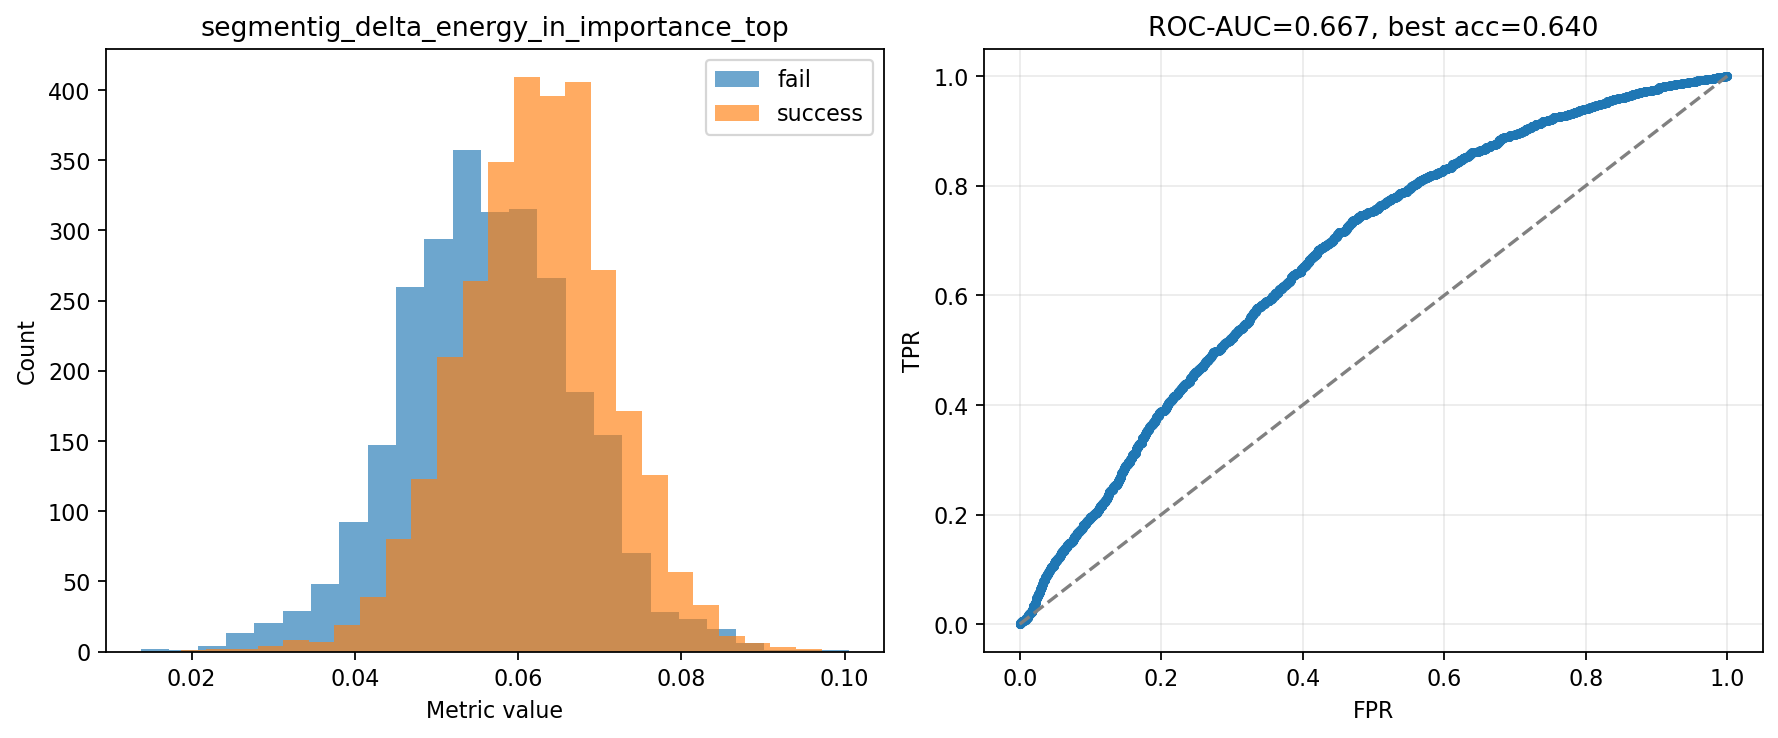

segmentig_delta_energy_importance_bins_top10_linear | roc_auc=0.666 | best_acc=0.637


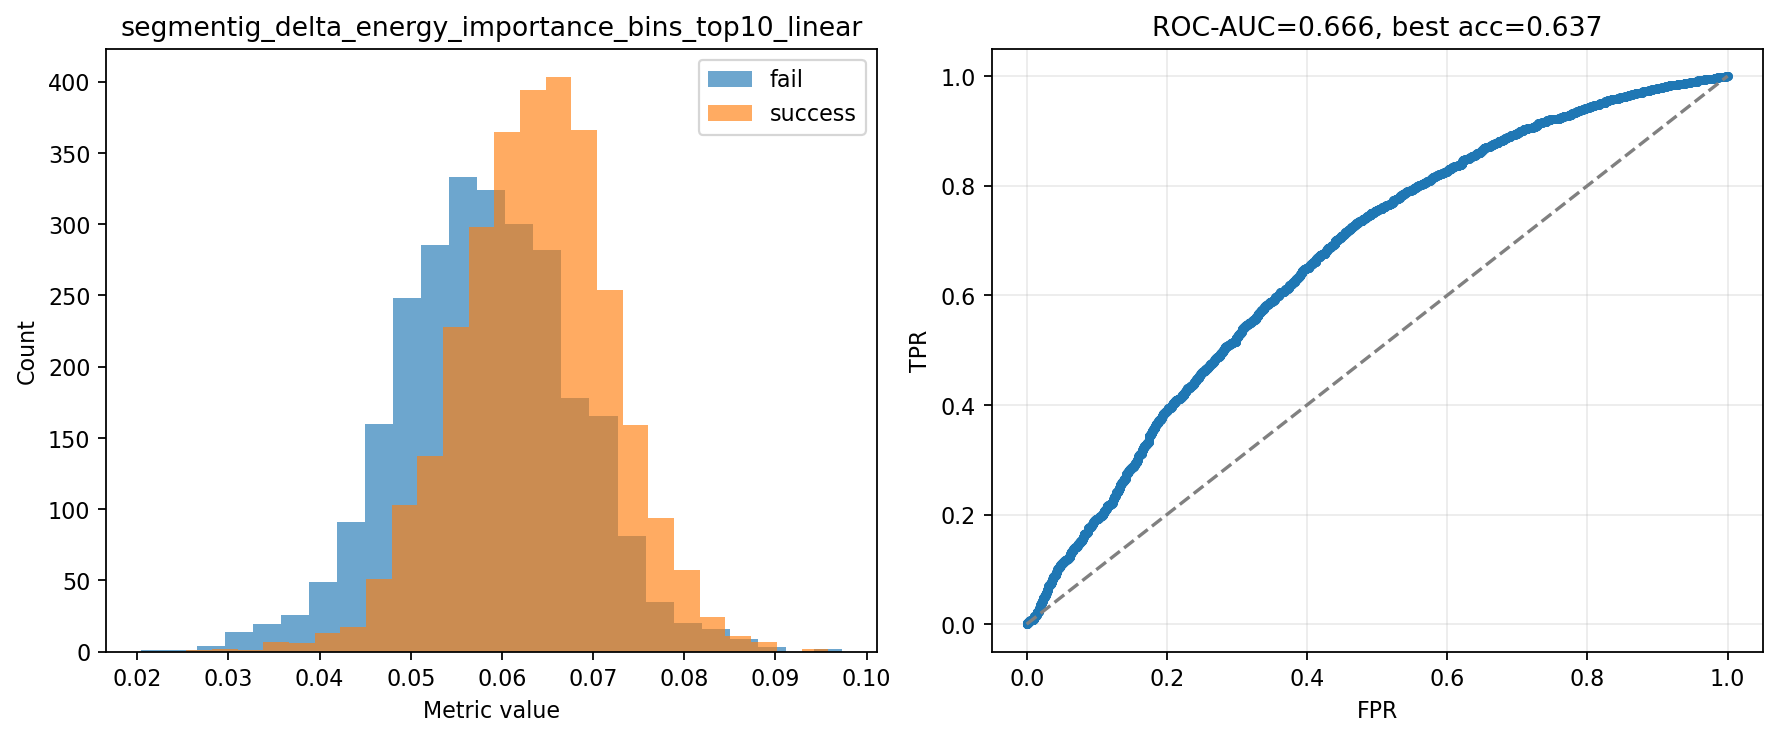

segmentig_delta_energy_importance_bins_top10_exp | roc_auc=0.665 | best_acc=0.636


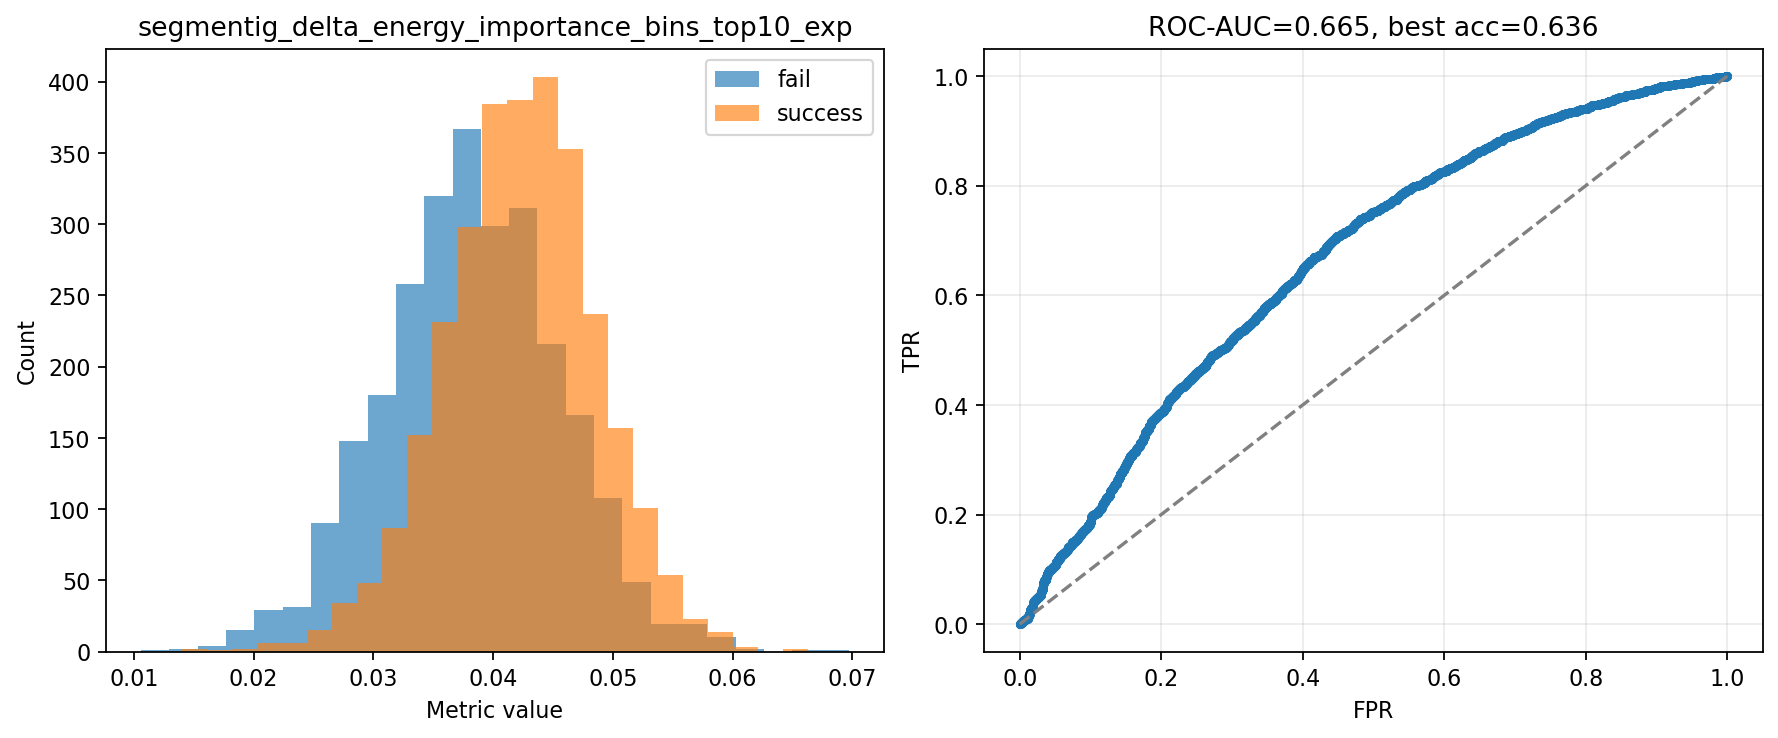

segmentig_delta_energy_importance_bins_top10_reciprocal | roc_auc=0.663 | best_acc=0.635


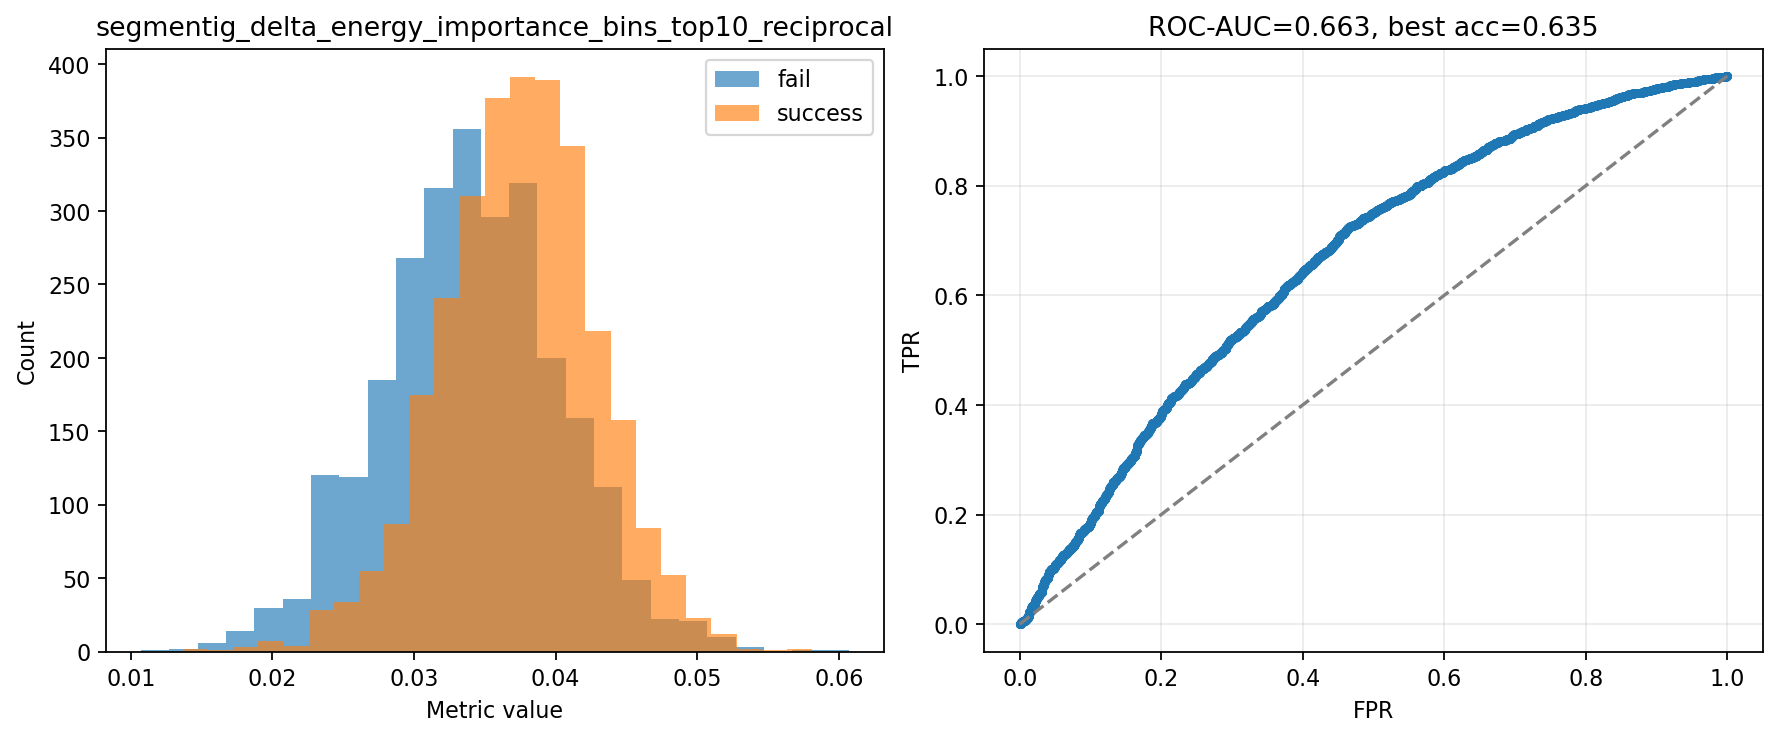

segmentig_delta_energy_importance_bins_top25_exp | roc_auc=0.663 | best_acc=0.634


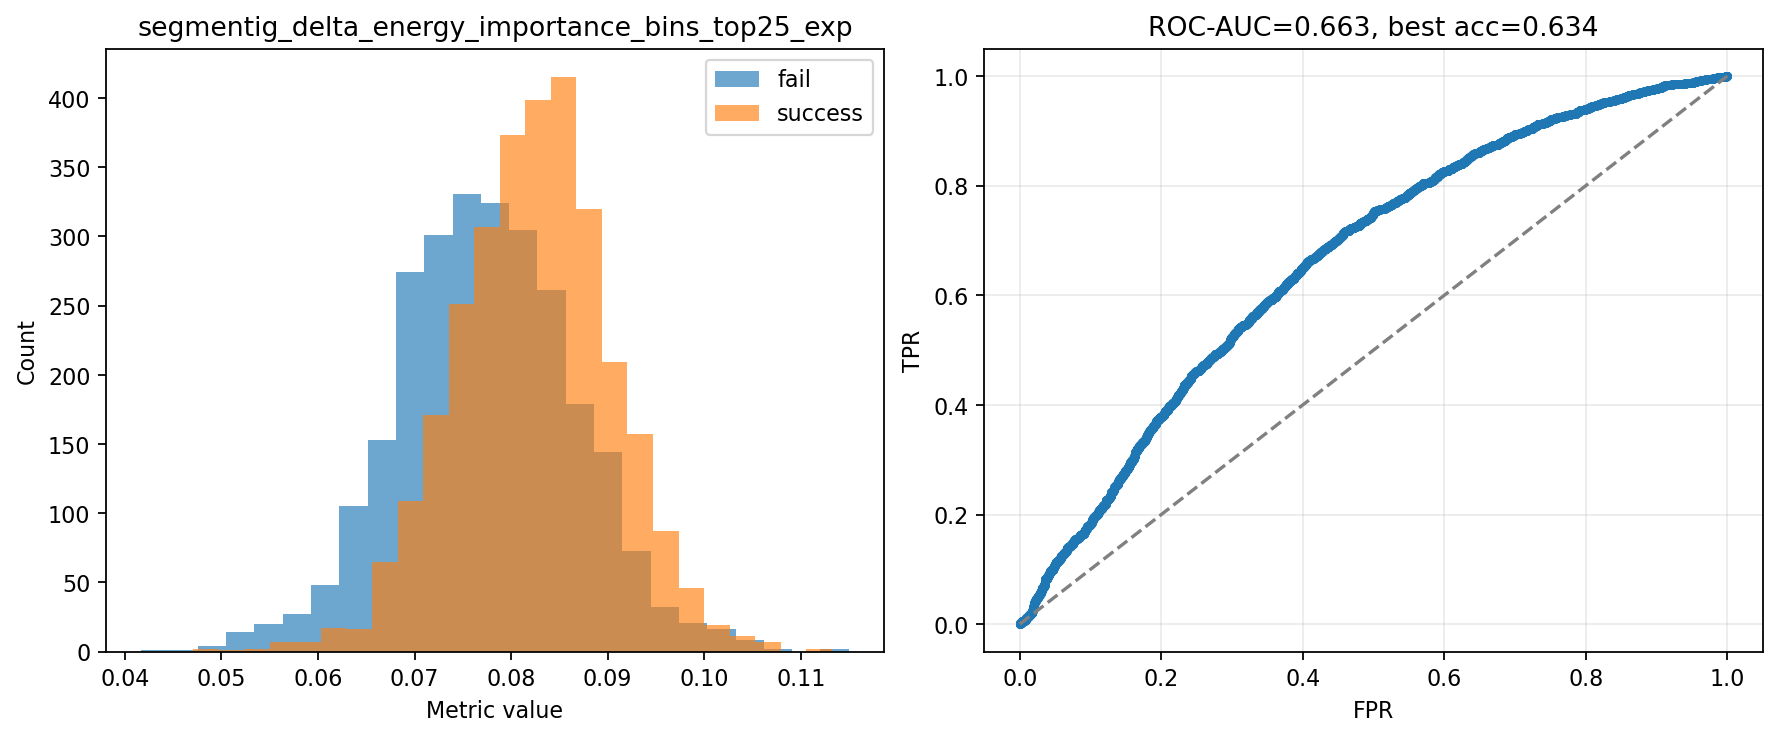

segmentig_delta_energy_importance_bins_top25_reciprocal | roc_auc=0.662 | best_acc=0.633


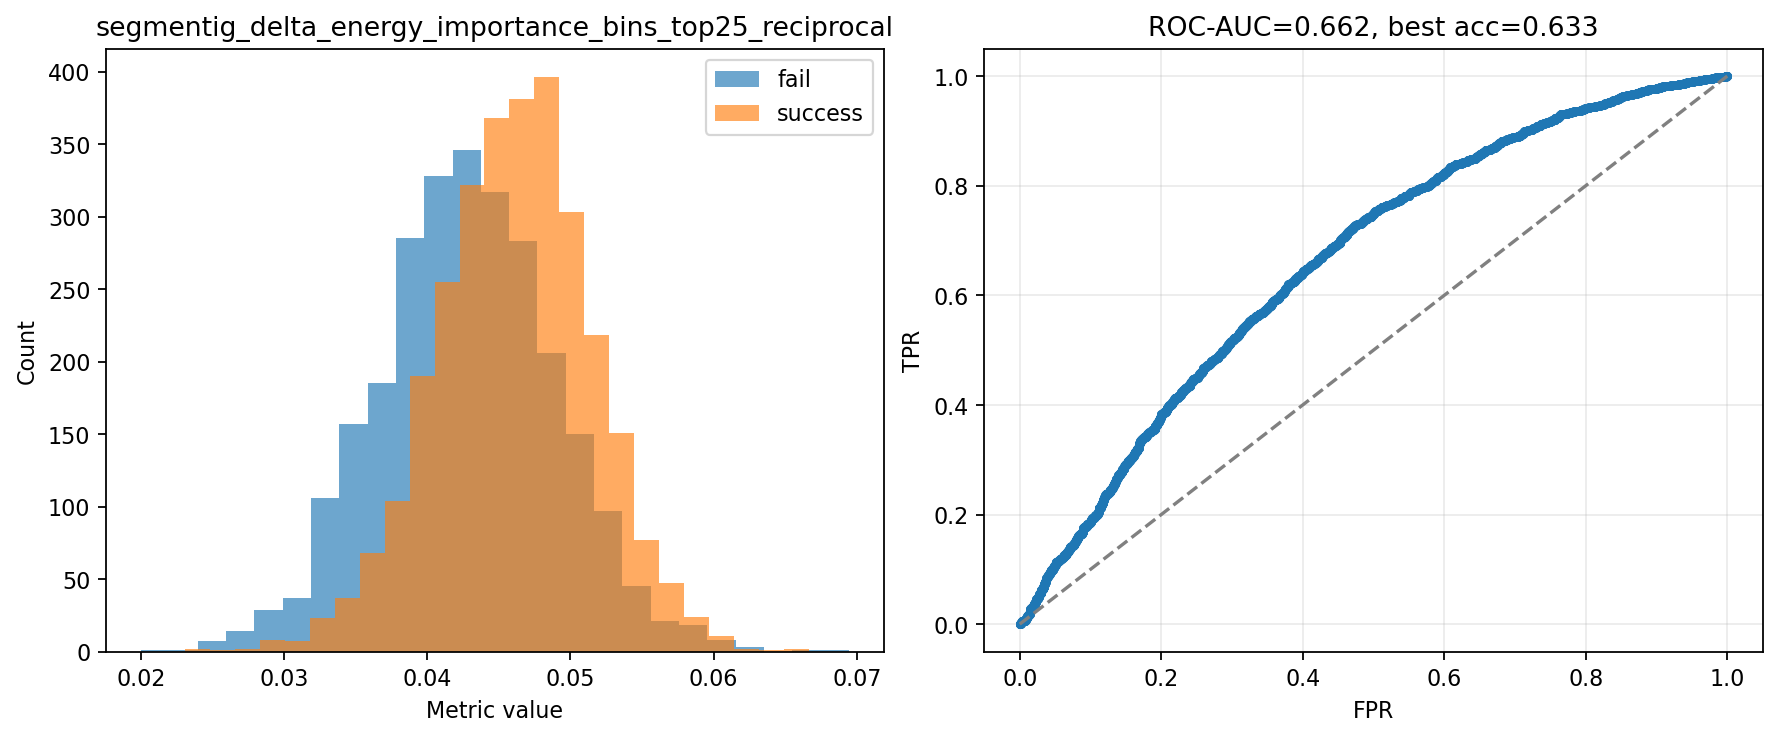

segmentig_delta_energy_importance_bins_top50_reciprocal | roc_auc=0.661 | best_acc=0.633


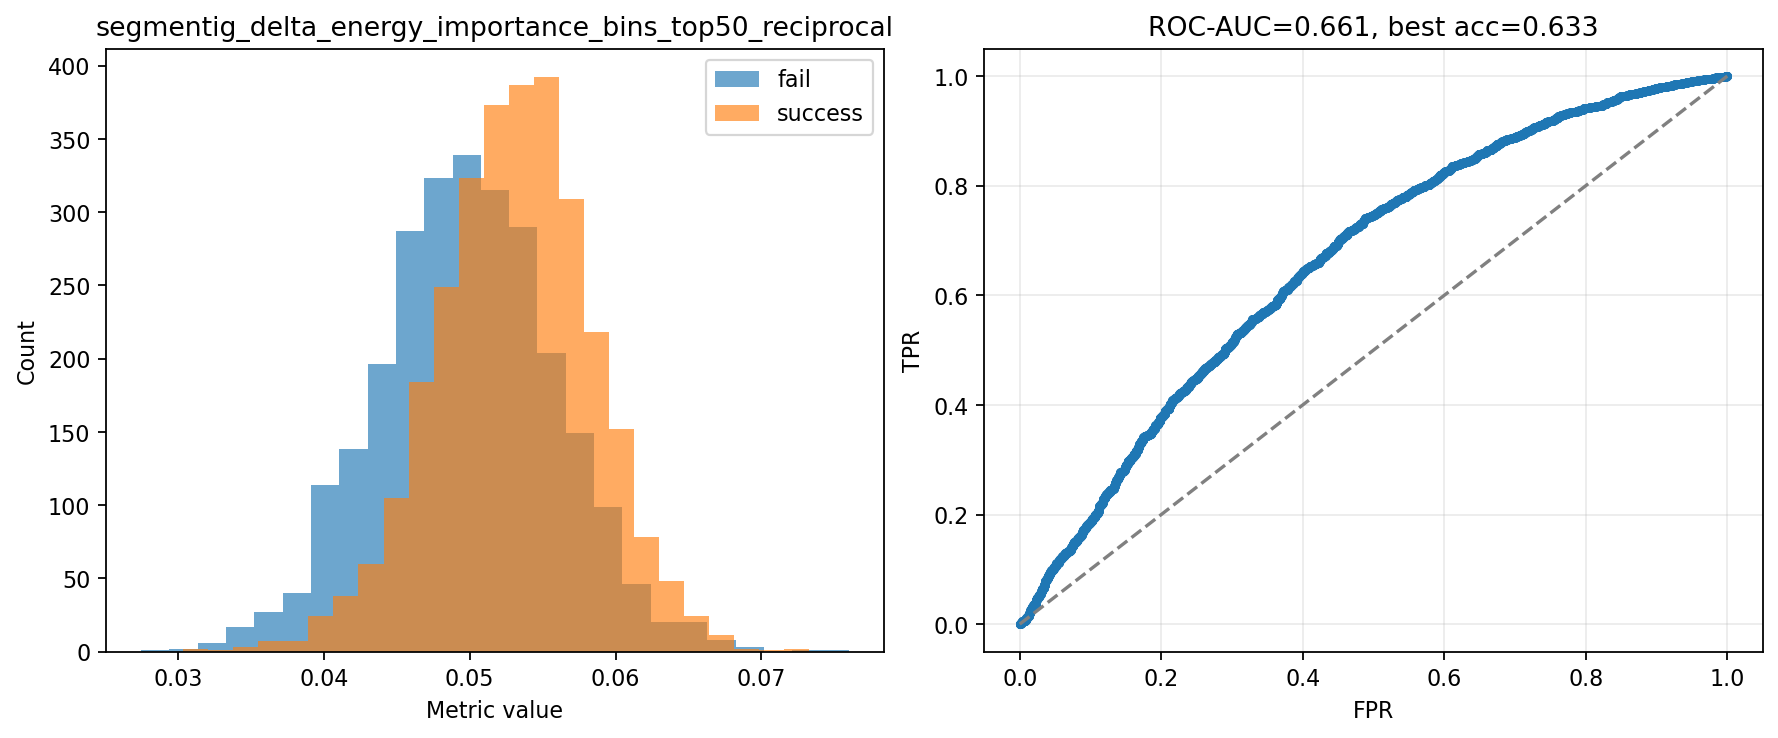

segmentig_delta_energy_importance_bins_top100_reciprocal | roc_auc=0.661 | best_acc=0.633


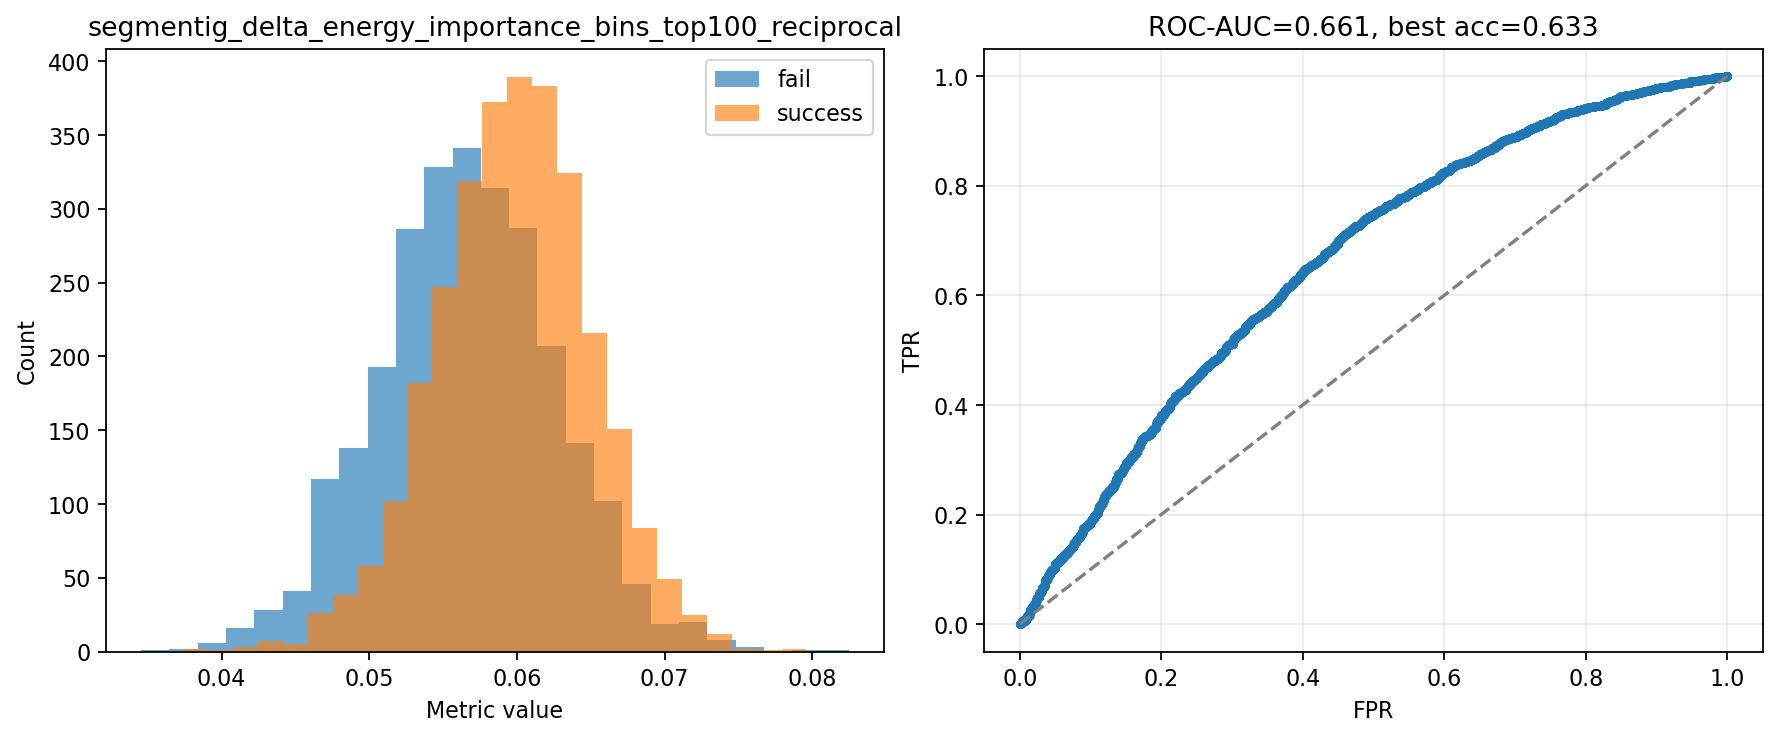

segmentig_delta_energy_importance_bins_top50_exp | roc_auc=0.656 | best_acc=0.627


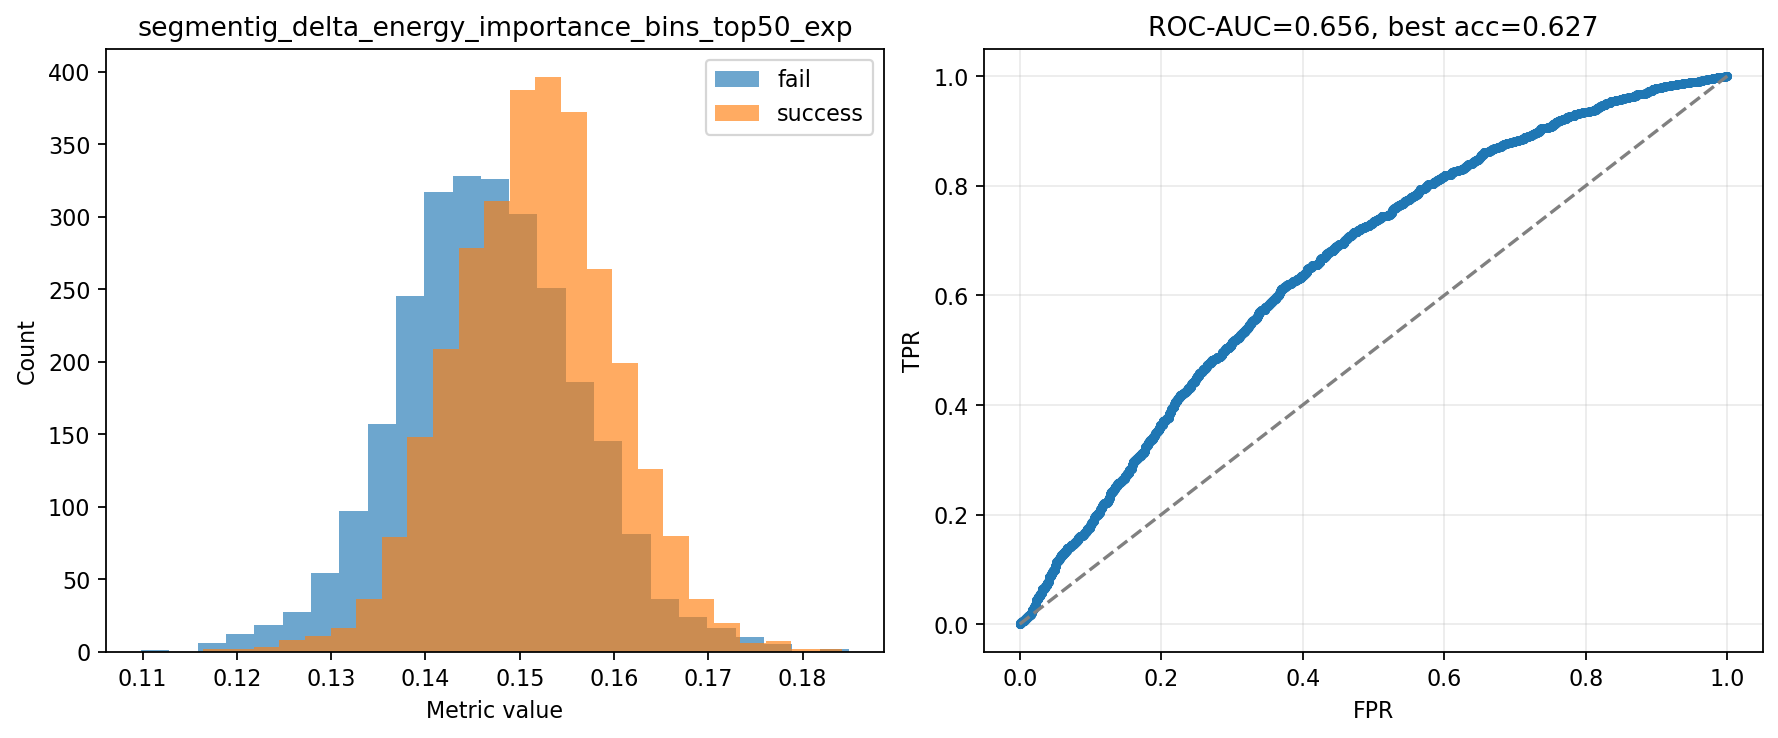

segmentig_delta_energy_importance_bins_top25_linear | roc_auc=0.657 | best_acc=0.627


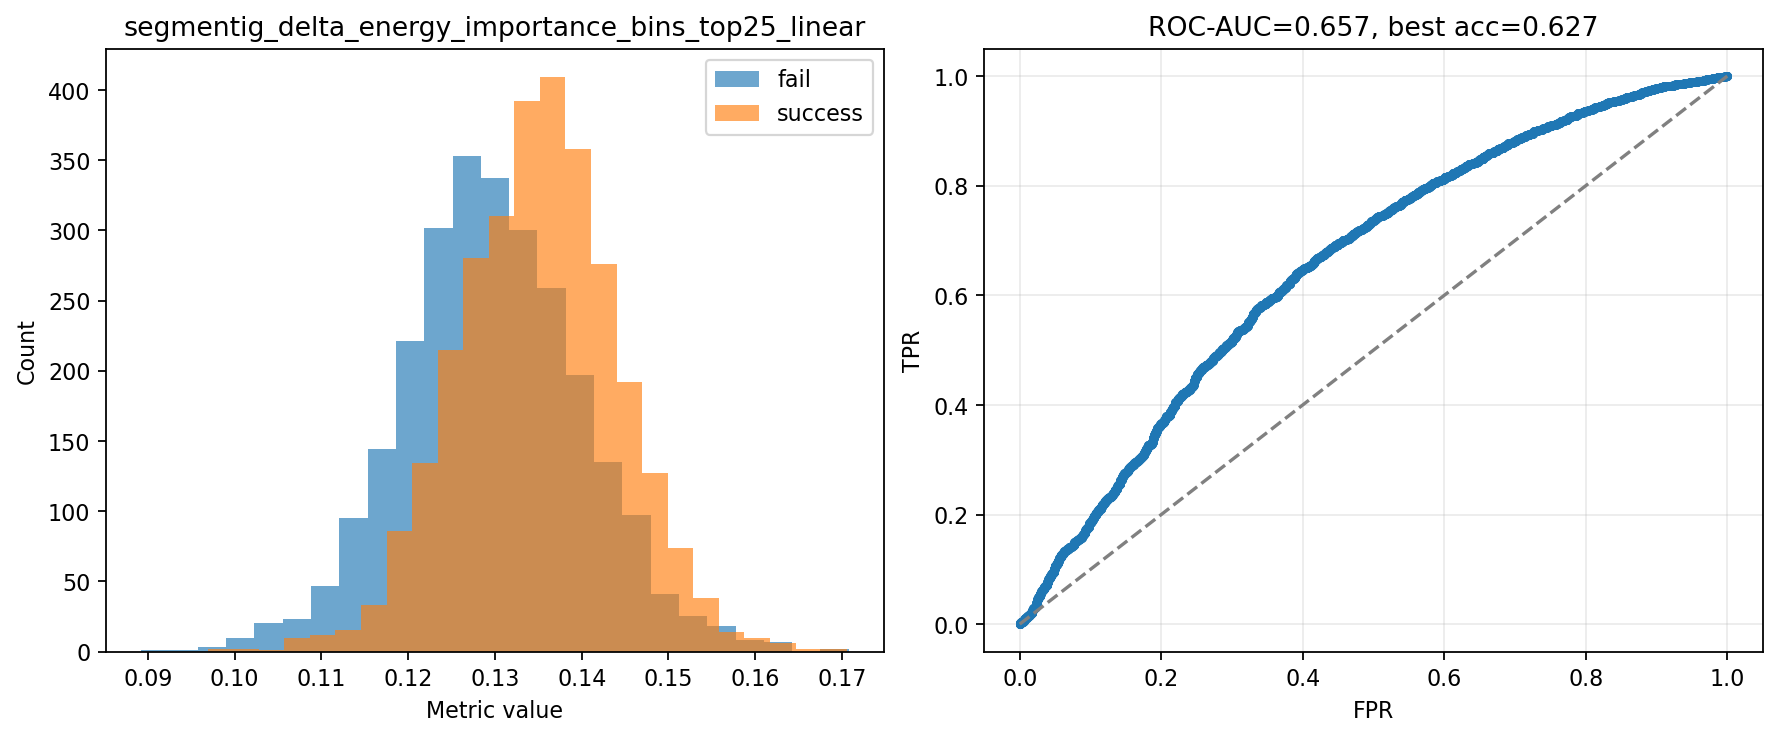

segmentig_delta_energy_importance_bins_top100_exp | roc_auc=0.647 | best_acc=0.619


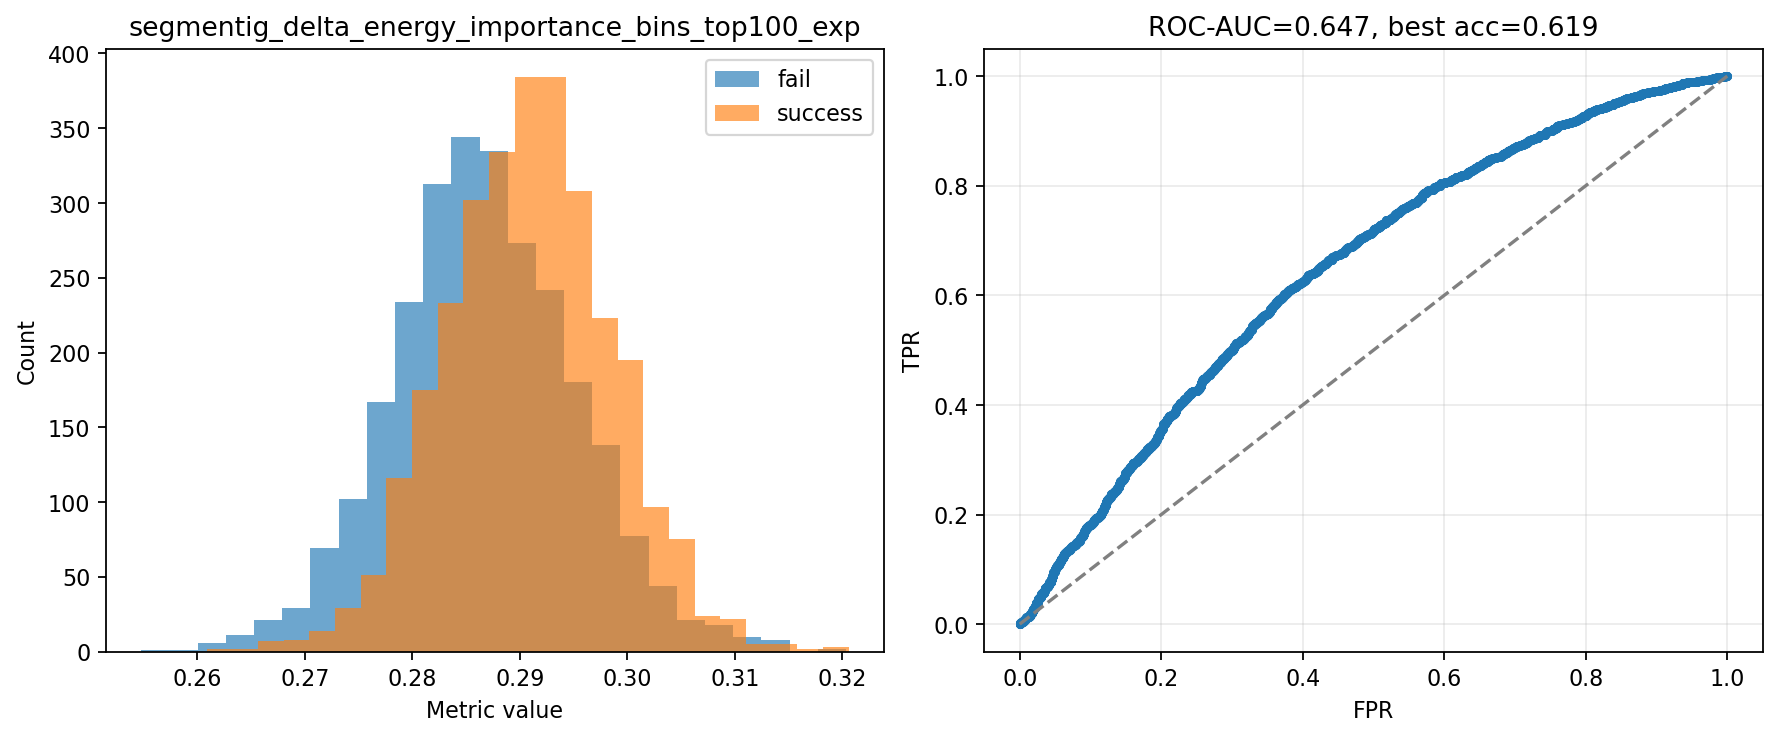

segmentig_delta_energy_importance_bins_top50_linear | roc_auc=0.640 | best_acc=0.612


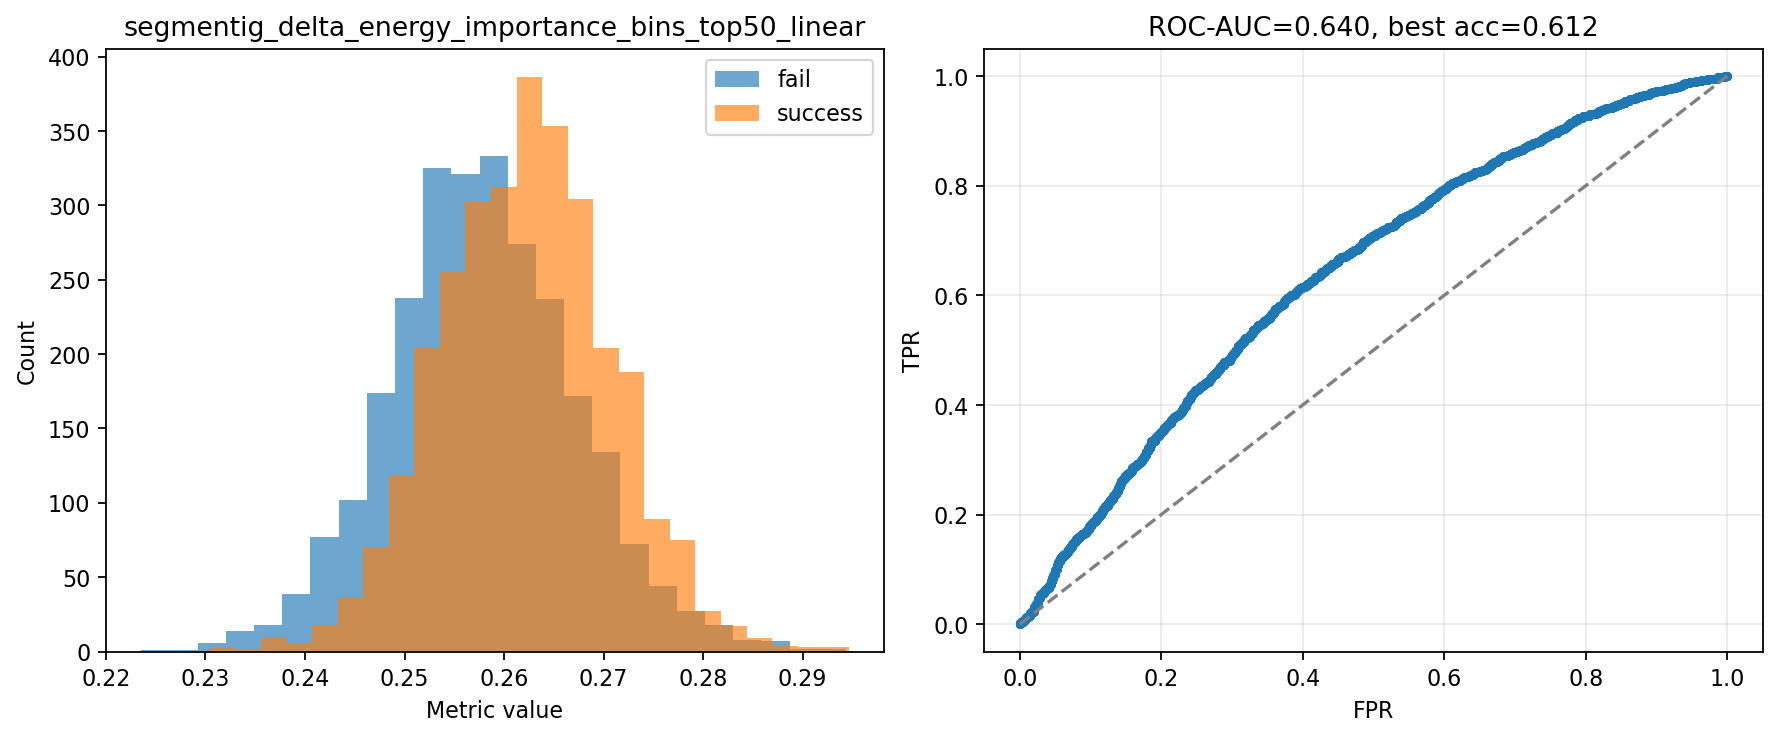

segmentig_delta_energy_importance_bins_top100_linear | roc_auc=0.626 | best_acc=0.607


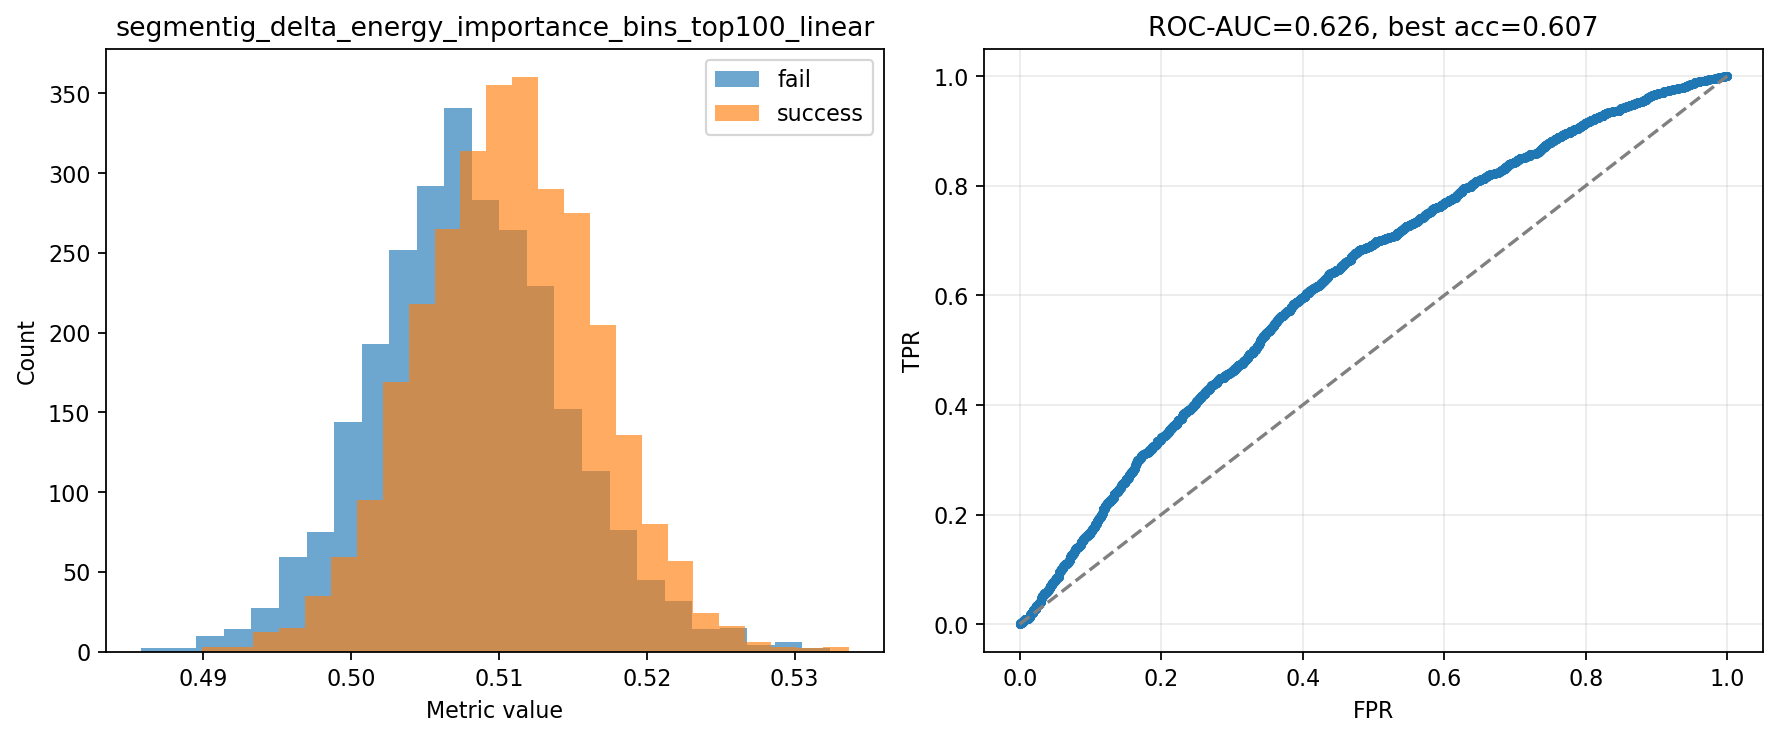

segmentig_delta_importance_product_signed | roc_auc=0.568 | best_acc=0.559


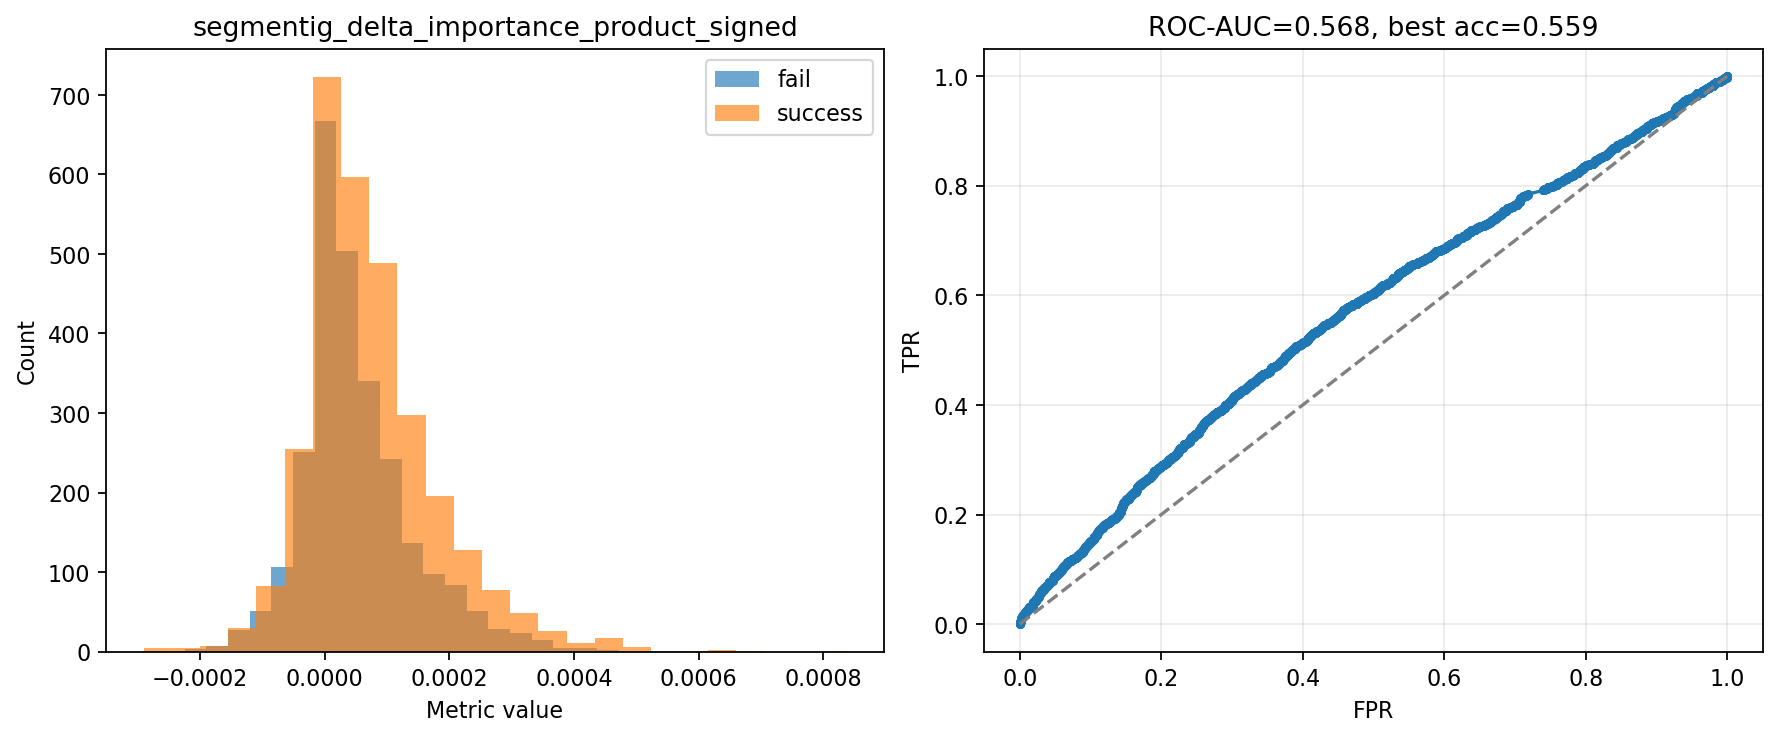

segmentig_delta_importance_product_unsigned | roc_auc=0.563 | best_acc=0.550


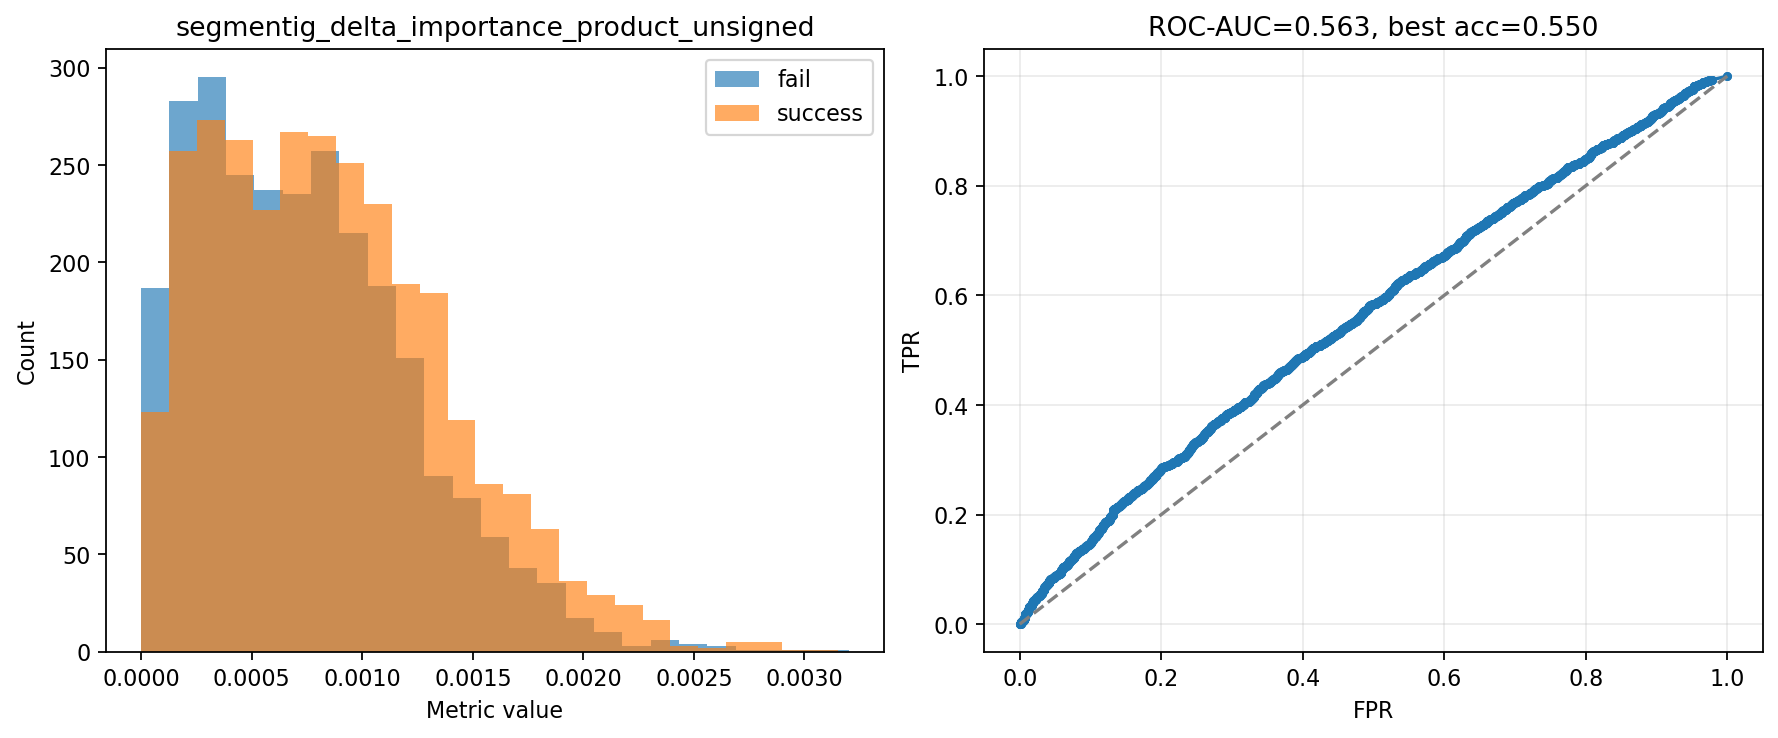

In [3]:
# SegmentIG0.1-only comparison: baseline + soft variants
rows_df = pd.DataFrame(sf['rows'])
quality_df = pd.DataFrame(sf['quality']).sort_values(['best_accuracy', 'roc_auc'], ascending=False)

baseline_metric = 'segmentig_delta_energy_in_importance_top'
product_metrics = [
    'segmentig_delta_importance_product_signed',
    'segmentig_delta_importance_product_unsigned',
]
cutoffs = [100, 50, 25, 10]
families = ['linear', 'reciprocal', 'exp']
binned_metrics = [
    f'segmentig_delta_energy_importance_bins_top{cutoff}_{family}'
    for cutoff in cutoffs
    for family in families
]
soft_metrics = [baseline_metric] + product_metrics + binned_metrics

known_quality = set(quality_df['metric'])
missing = [m for m in soft_metrics if m not in rows_df.columns or m not in known_quality]
if missing:
    raise RuntimeError(
        f'Нет soft-метрик {missing}. Перезапусти ячейку с '
        'run_segmentig_success_failure_metrics(), чтобы пересчитать sf.'
    )

def metric_family(metric):
    if metric == baseline_metric:
        return 'baseline_top5_binary'
    if metric.endswith('_signed'):
        return 'product_signed'
    if metric.endswith('_unsigned'):
        return 'product_unsigned'
    return metric.rsplit('_', 1)[-1] 

def metric_cutoff(metric):
    if '_bins_top' not in metric:
        return pd.NA
    return int(metric.split('_bins_top', 1)[1].split('_', 1)[0])

soft_quality = quality_df[quality_df['metric'].isin(soft_metrics)].copy()
soft_quality['family'] = soft_quality['metric'].map(metric_family)
soft_quality['cutoff_percent'] = soft_quality['metric'].map(metric_cutoff)
soft_quality = soft_quality.sort_values(['best_accuracy', 'roc_auc'], ascending=False)
display(soft_quality[['metric', 'family', 'cutoff_percent', 'roc_auc', 'best_accuracy', 'best_threshold', 'best_direction']])

success_means = rows_df.groupby('success')[soft_metrics].mean(numeric_only=True).T
success_means = success_means.rename(columns={False: 'fail_mean', True: 'success_mean'})
for col in ['fail_mean', 'success_mean']:
    if col not in success_means.columns:
        success_means[col] = float('nan')
success_means = success_means.reset_index(names='metric')
success_means['family'] = success_means['metric'].map(metric_family)
success_means['cutoff_percent'] = success_means['metric'].map(metric_cutoff)
display(success_means[['metric', 'family', 'cutoff_percent', 'fail_mean', 'success_mean']])

for _, row in soft_quality.iterrows():
    print(f"{row['metric']} | roc_auc={row['roc_auc']:.3f} | best_acc={row['best_accuracy']:.3f}")
    display(Image(filename=row['figure_path']))


## Logistic regression по 1%-бинам

Обучаем регуляризованную логистическую регрессию на 100 признаках: каждый признак — доля `|Δ|` в 1%-бине, где нейроны отсортированы по `|SegmentIG[0;0.1]|`. ElasticNet-CV подбирает силу регуляризации и смесь L1/L2; коэффициенты показывают, какие ранговые зоны важности модель считает полезными для разделения success/fail.


bin logreg cache: new_experiments/outputs/patch_success_analysis/cache/binmetrics_elasticnet_bin_logreg_v1_dd262bab8608a9f7.pkl
loaded_from_cache=True
n_examples=5646, n_features=100
best_cv_auc=0.730, in_sample_auc=0.748
best_C=100, best_l1_ratio=1.00, intercept=-0.1693
nonzero_coefficients=83/100


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
3,4,3,4,190.364191,190.364191,True
35,36,35,36,163.479044,163.479044,True
91,92,91,92,117.034147,117.034147,True
22,23,22,23,106.545851,106.545851,True
59,60,59,60,102.859476,102.859476,True
99,100,99,100,95.466031,95.466031,True
28,29,28,29,89.203949,89.203949,True
82,83,82,83,79.223193,79.223193,True
61,62,61,62,74.258662,74.258662,True
17,18,17,18,72.617115,72.617115,True


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
27,28,27,28,-170.692758,170.692758,True
68,69,68,69,-166.624122,166.624122,True
62,63,62,63,-163.410805,163.410805,True
25,26,25,26,-162.349704,162.349704,True
45,46,45,46,-133.300636,133.300636,True
24,25,24,25,-112.599703,112.599703,True
67,68,67,68,-106.494440,106.494440,True
30,31,30,31,-93.501526,93.501526,True
85,86,85,86,-83.438525,83.438525,True
98,99,98,99,-70.614976,70.614976,True


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
0,1,0,1,66.721931,66.721931,True
1,2,1,2,0.000000,0.000000,False
2,3,2,3,0.000000,0.000000,False
3,4,3,4,190.364191,190.364191,True
4,5,4,5,39.643294,39.643294,True
...,...,...,...,...,...,...
95,96,95,96,0.000000,0.000000,False
96,97,96,97,-5.915142,5.915142,True
97,98,97,98,31.729481,31.729481,True
98,99,98,99,-70.614976,70.614976,True


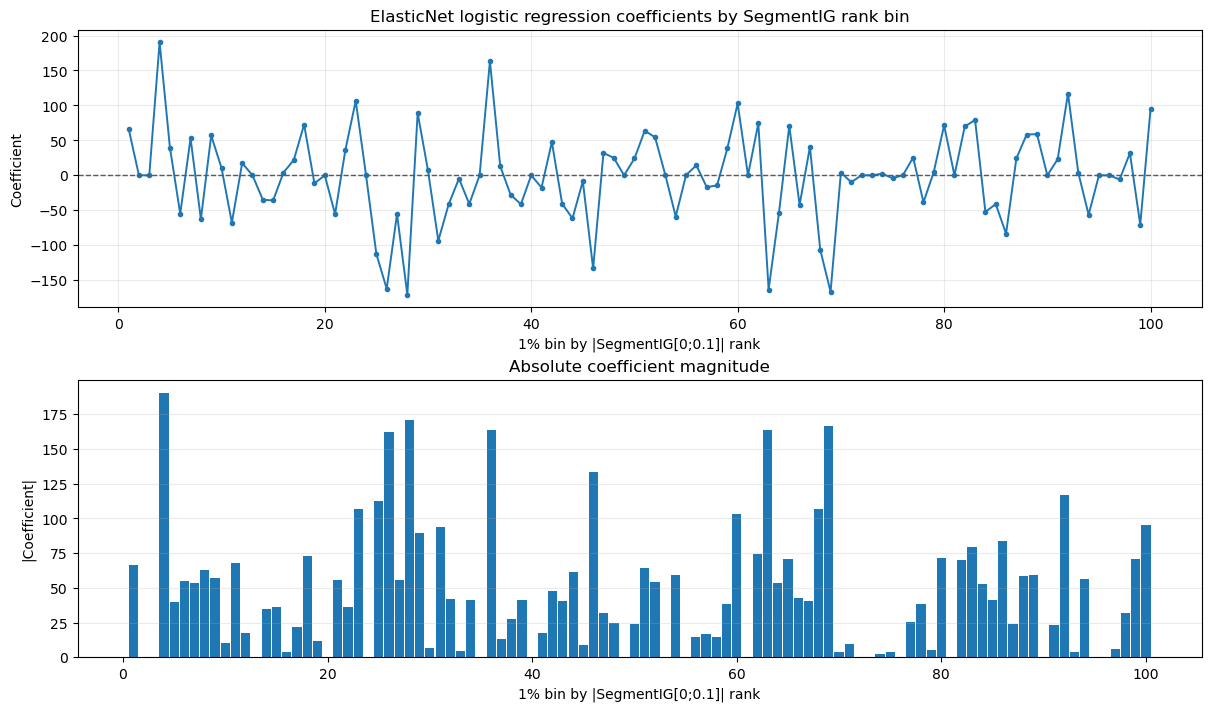

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from patch_success_analysis import bin_metrics

force_bin_logreg_recompute = False
learned_score_col = "segmentig_logreg_bin_score"

bin_logreg_result = bin_metrics.compute_or_load_elasticnet_bin_logreg(
    exp,
    rows_df,
    force=force_bin_logreg_recompute,
)
coef_df = bin_logreg_result["coef_df"]
rows_df.loc[:, learned_score_col] = bin_logreg_result["score_series"]
metrics = bin_logreg_result["metrics"]

print(f"bin logreg cache: {bin_logreg_result['cache_path']}")
print(f"loaded_from_cache={bin_logreg_result['loaded_from_cache']}")
print(f"n_examples={metrics['n_examples']}, n_features={metrics['n_features']}")
print(f"best_cv_auc={metrics['best_cv_auc']:.3f}, in_sample_auc={metrics['train_auc']:.3f}")
print(
    f"best_C={metrics['best_C']:.4g}, "
    f"best_l1_ratio={metrics['best_l1_ratio']:.2f}, "
    f"intercept={metrics['intercept']:.4g}"
)
print(f"nonzero_coefficients={metrics['nonzero_coefficients']}/100")

display(coef_df.sort_values('coef', ascending=False).head(15))
display(coef_df.sort_values('coef', ascending=True).head(15))
display(coef_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(coef_df['bin'], coef_df['coef'], marker='o', linewidth=1.4, markersize=3)
axes[0].axhline(0, color='0.35', linestyle='--', linewidth=1)
axes[0].set_title('ElasticNet logistic regression coefficients by SegmentIG rank bin')
axes[0].set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
axes[0].set_ylabel('Coefficient')
axes[0].grid(alpha=0.25)
axes[1].bar(coef_df['bin'], coef_df['abs_coef'], width=0.9)
axes[1].set_title('Absolute coefficient magnitude')
axes[1].set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
axes[1].set_ylabel('|Coefficient|')
axes[1].grid(axis='y', alpha=0.25)
plt.show()

### Проверка: меньше бинов и более мелкие 0.1%-бины

Тут проверяем две вещи. Во-первых, что будет, если для 1%-бинов брать только первые 5 или 10 бинов, а не все 100. Во-вторых, пробуем более мелкую нарезку по 0.1% и смотрим окна `1%`, `5%`, `10%`. Если обученные веса реально помогают, это должно быть видно на validation, а не только на train.


bin granularity cache: new_experiments/outputs/patch_success_analysis/cache/binmetrics_bin_granularity_v1_41d85f8e96352d56.pkl
loaded_from_cache=True


,variant,model_kind,n_features,C,train_acc,train_auc,val_acc,val_auc,all_best_acc,all_auc
18,0.1% bins: top 5% / L2 C=0.003,fixed_l2,50,0.003000,0.685,0.7082,0.680,0.7448,0.637797,0.668043
17,0.1% bins: top 5% / L2 C=0.01,fixed_l2,50,0.010000,0.695,0.7285,0.680,0.7429,0.636734,0.667805
2,1% bins: top 5% / L2 C=0.01,fixed_l2,5,0.010000,0.685,0.6949,0.670,0.7426,0.637265,0.666767
20,0.1% bins: top 10% / L2 CV,cv_l2,100,0.000056,0.680,0.7056,0.665,0.7449,0.640099,0.668799
19,0.1% bins: top 5% / L2 C=0.001,fixed_l2,50,0.001000,0.680,0.7005,0.665,0.7437,0.640099,0.667506
1,1% bins: top 5% / L2 C=0.03,fixed_l2,5,0.030000,0.685,0.6943,0.665,0.7437,0.637265,0.666868
9,1% bins: top 10% / L2 C=0.001,fixed_l2,10,0.001000,0.675,0.6986,0.665,0.7369,0.635494,0.664981
23,0.1% bins: top 10% / L2 C=0.003,fixed_l2,100,0.003000,0.710,0.7521,0.660,0.7497,0.644704,0.681171
24,0.1% bins: top 10% / L2 C=0.001,fixed_l2,100,0.001000,0.690,0.7230,0.660,0.7471,0.642047,0.674082
15,0.1% bins: top 5% / L2 CV,cv_l2,50,0.000010,0.680,0.6978,0.660,0.7438,0.639214,0.667071


,method,source,weights,train_acc,val_acc,val_auc
0,segmentig_delta_energy_importance_bins_top10_l...,precomputed,,0.665,0.700,0.7461
1,0.1% top10 linear,manual_0.1%,"[1, 0.99, ..., 0.01]",0.665,0.690,0.7443
2,segmentig_delta_energy_importance_bins_top25_exp,precomputed,,0.665,0.685,0.7426
3,segmentig_hand_rank_top6_delta_frac,precomputed,,0.675,0.680,0.7475
4,segmentig_hand_rank_top5_delta_frac,precomputed,,0.670,0.680,0.7472
5,0.1% top5 flat,manual_0.1%,"[1, 1, ..., 1]",0.670,0.680,0.7472
6,segmentig_delta_energy_in_importance_top,precomputed,,0.670,0.680,0.7468
7,segmentig_hand_overlap_top5_delta_in_topA,precomputed,,0.670,0.680,0.7468
8,ML: 0.1% bins: top 5% / L2 C=0.003,ML,learned,0.685,0.680,0.7448
9,ML: 0.1% bins: top 5% / L2 C=0.01,ML,learned,0.695,0.680,0.7429


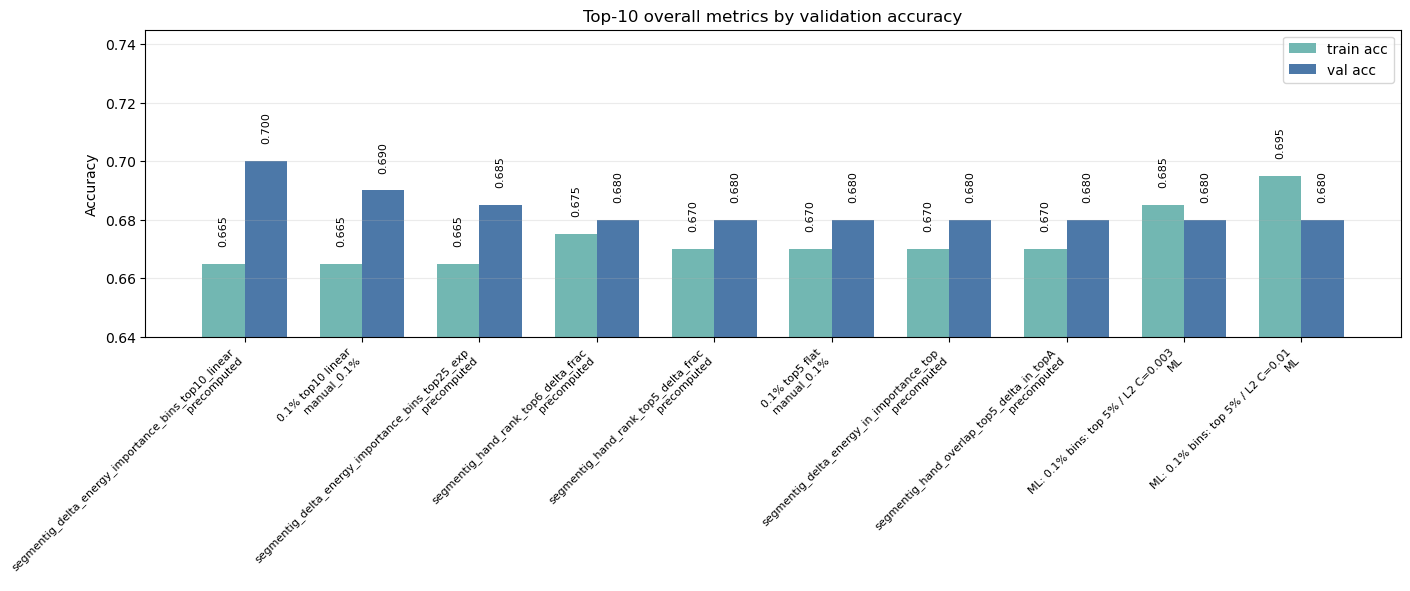

,method,weights,train_acc,val_acc,val_auc,kind
0,0.1% top10 linear,"[1, 0.99, ..., 0.01]",0.665,0.690,0.7443,manual_0.1%
1,top5% flat,"[1, 1, ..., 1]",0.670,0.680,0.7472,manual
2,0.1% top5 flat,"[1, 1, ..., 1]",0.670,0.680,0.7472,manual_0.1%
3,best ML\n0.1% bins: top 5%\nL2 C=0.003,learned,0.685,0.680,0.7448,learned
4,top10% flat,"[1, 1, ..., 1]",0.670,0.675,0.7428,manual
5,0.1% top10 flat,"[1, 1, ..., 1]",0.670,0.675,0.7428,manual_0.1%
6,top10% reciprocal,"[1, 1/2, ..., 1/10]",0.650,0.670,0.7409,manual
7,0.1% top5 sqrt_reciprocal,"[1, 1/sqrt(2), ..., 1/sqrt(50)]",0.645,0.665,0.7394,manual_0.1%
8,0.1% top10 sqrt_reciprocal,"[1, 1/sqrt(2), ..., 1/sqrt(100)]",0.665,0.665,0.7394,manual_0.1%
9,0.1% top5 exp,"[1, 0.933, ..., 0.0335]",0.645,0.660,0.7352,manual_0.1%


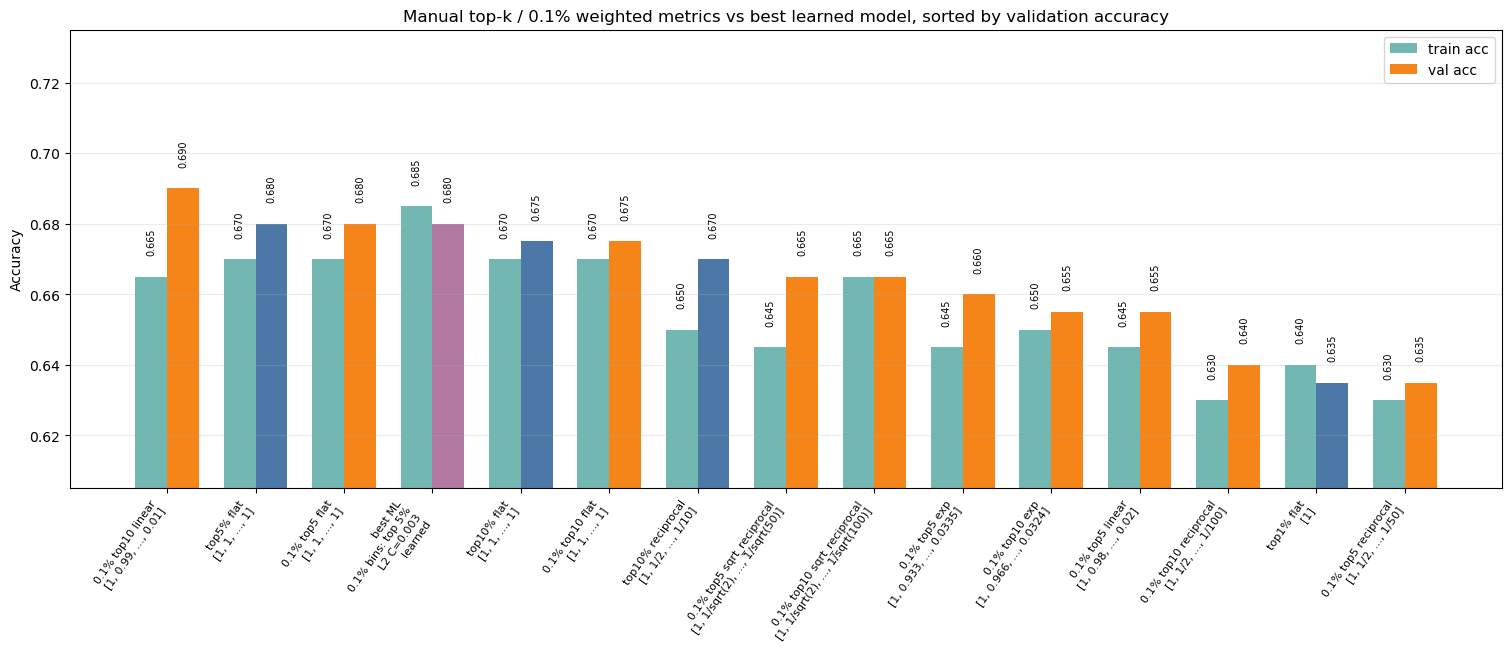

,method,cutoff_percent,weight_family,n_bins,weights,train_acc,val_acc,val_auc
0,0.1% top10 linear,10,linear,100,"[1, 0.99, ..., 0.01]",0.665,0.690,0.7443
1,0.1% top5 flat,5,flat,50,"[1, 1, ..., 1]",0.670,0.680,0.7472
2,0.1% top10 flat,10,flat,100,"[1, 1, ..., 1]",0.670,0.675,0.7428
3,0.1% top5 sqrt_reciprocal,5,sqrt_reciprocal,50,"[1, 1/sqrt(2), ..., 1/sqrt(50)]",0.645,0.665,0.7394
4,0.1% top10 sqrt_reciprocal,10,sqrt_reciprocal,100,"[1, 1/sqrt(2), ..., 1/sqrt(100)]",0.665,0.665,0.7394
5,0.1% top5 exp,5,exp,50,"[1, 0.933, ..., 0.0335]",0.645,0.660,0.7352
6,0.1% top10 exp,10,exp,100,"[1, 0.966, ..., 0.0324]",0.650,0.655,0.7426
7,0.1% top5 linear,5,linear,50,"[1, 0.98, ..., 0.02]",0.645,0.655,0.7407
8,0.1% top10 reciprocal,10,reciprocal,100,"[1, 1/2, ..., 1/100]",0.630,0.640,0.7169
9,0.1% top5 reciprocal,5,reciprocal,50,"[1, 1/2, ..., 1/50]",0.630,0.635,0.7148


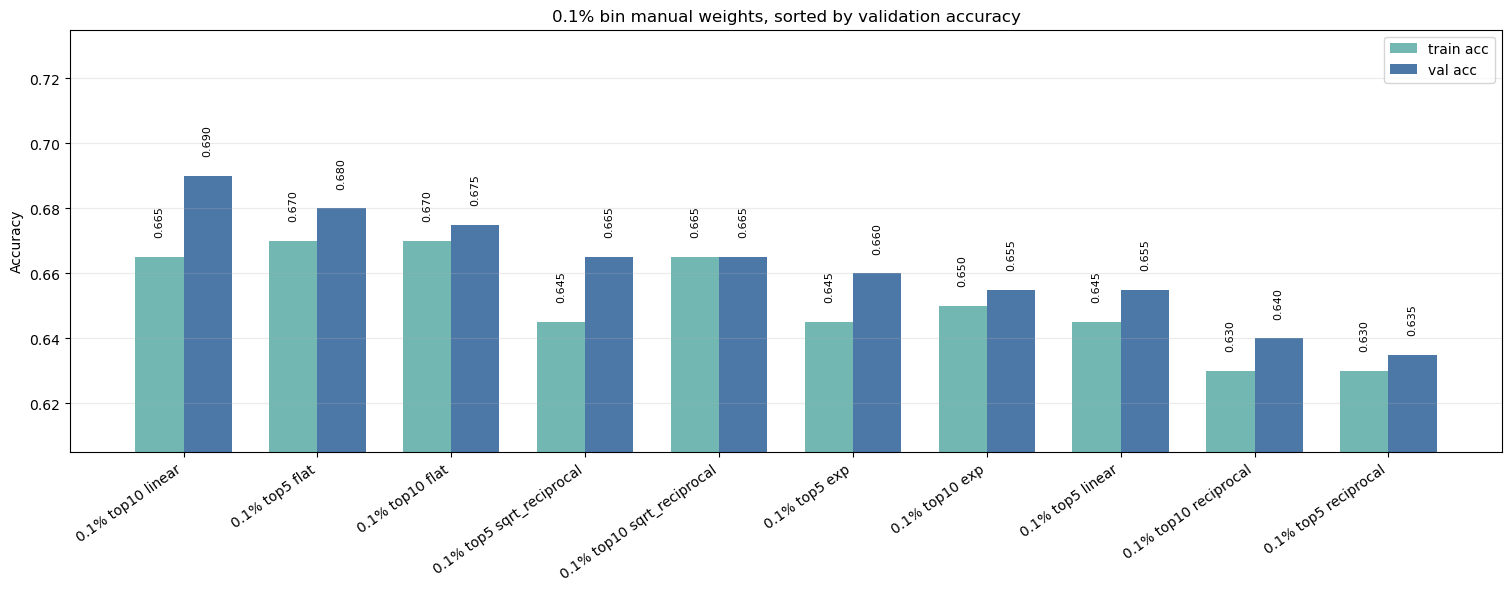

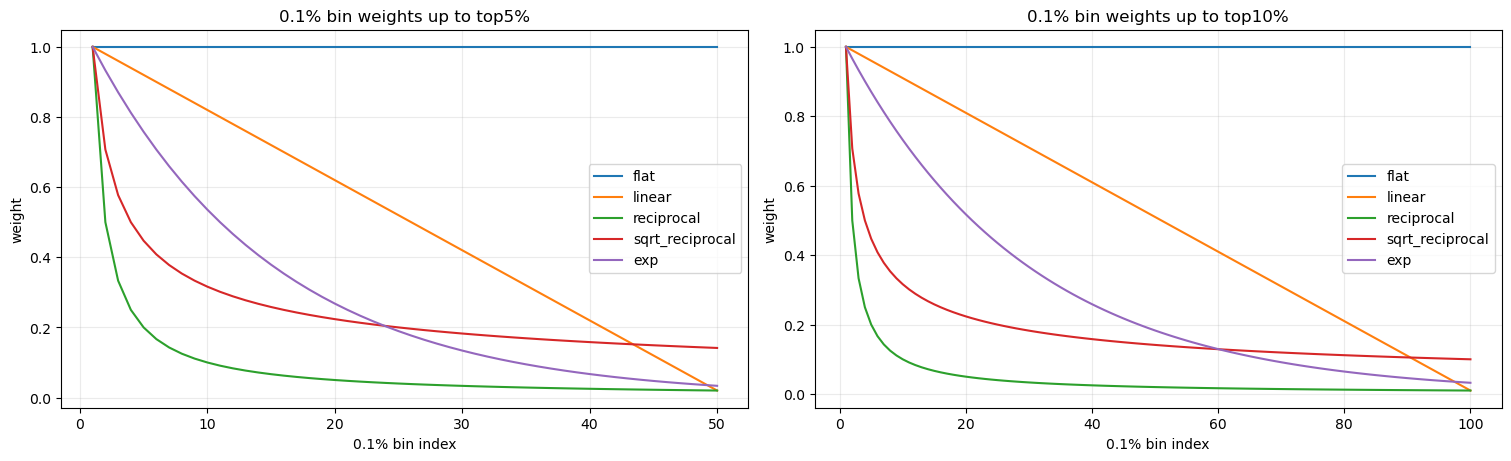

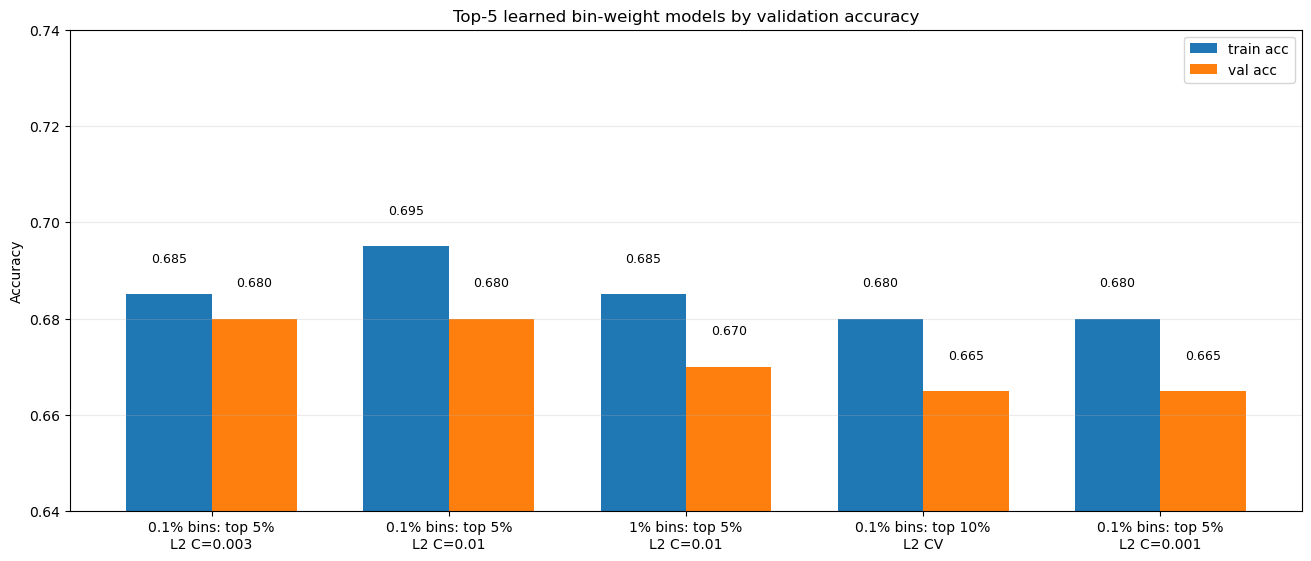

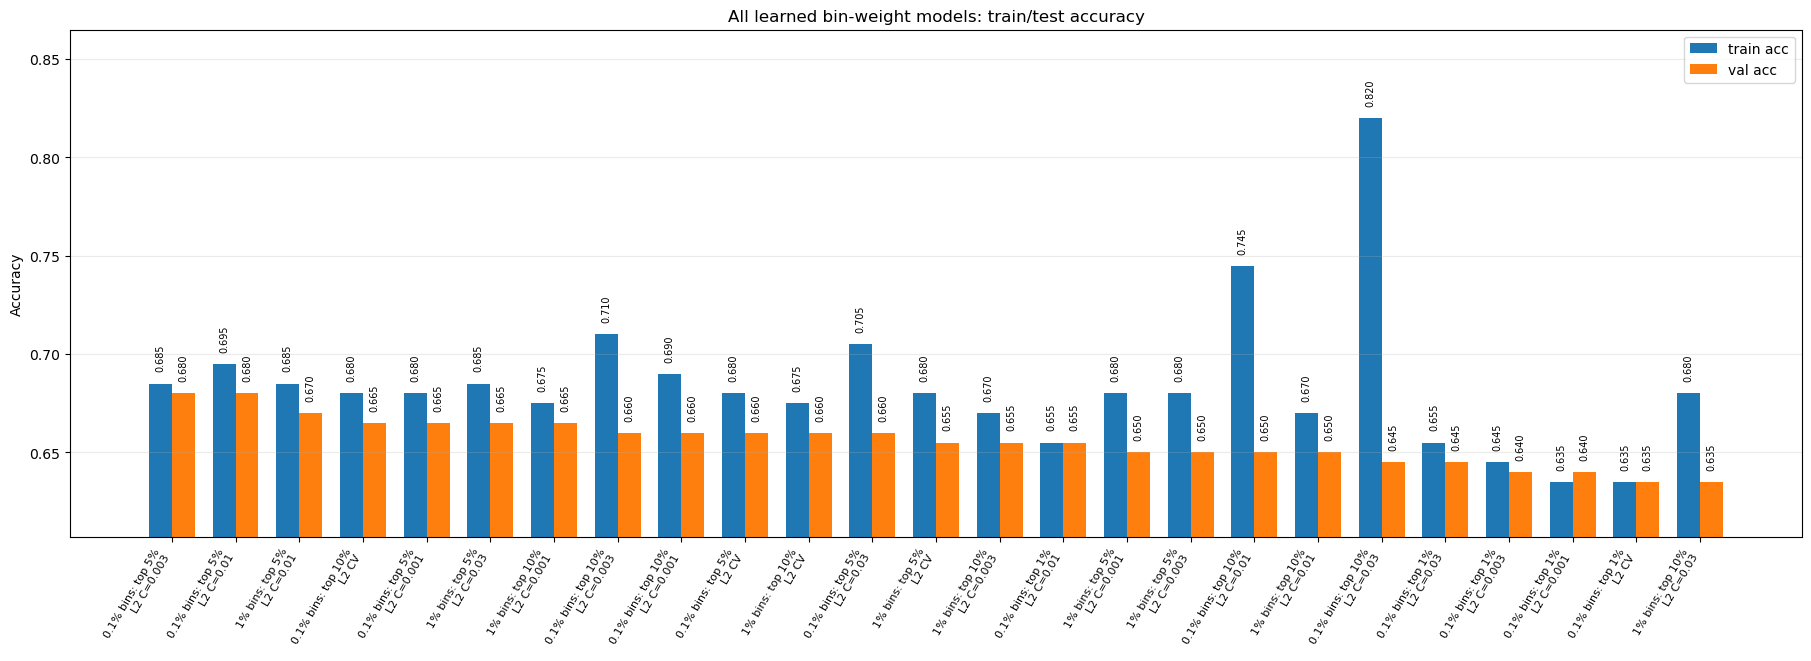

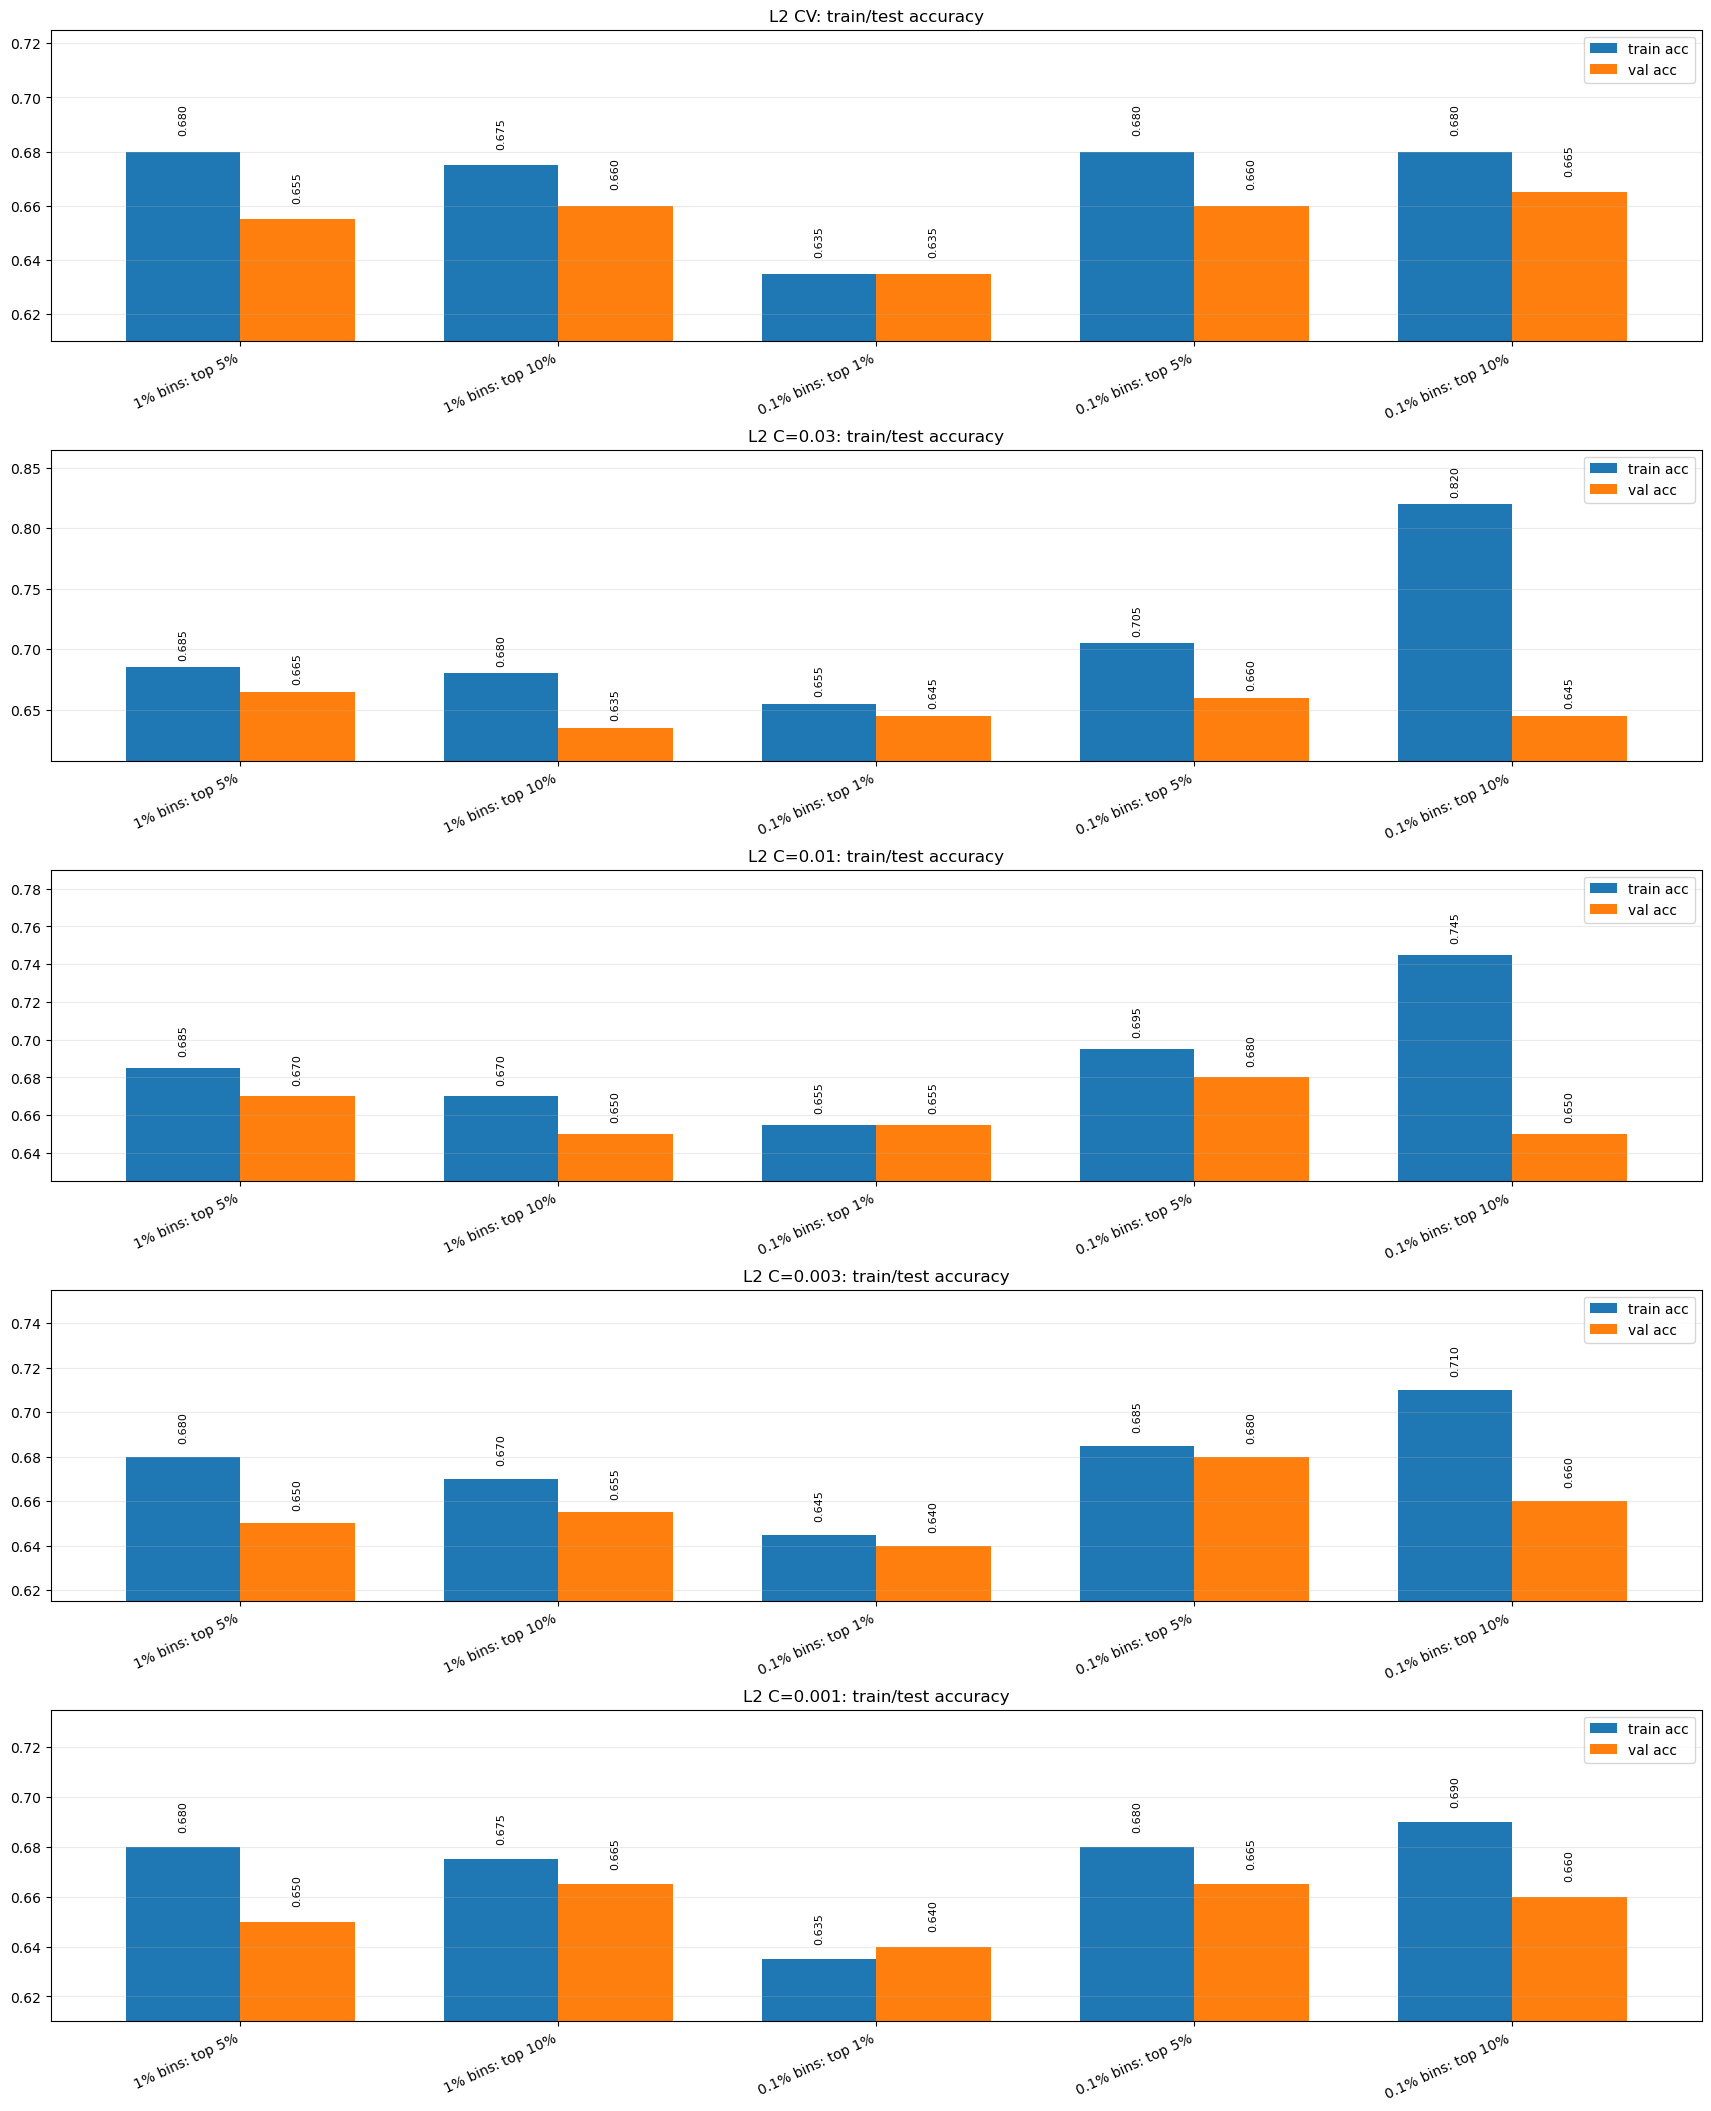

,regularization,variant,n_features,C,train_acc,val_acc,train_auc,val_auc
0,L2 C=0.001,0.1% bins: top 5% / L2 C=0.001,50,0.001000,0.680,0.665,0.7005,0.7437
1,L2 C=0.003,0.1% bins: top 5% / L2 C=0.003,50,0.003000,0.685,0.680,0.7082,0.7448
2,L2 C=0.01,0.1% bins: top 5% / L2 C=0.01,50,0.010000,0.695,0.680,0.7285,0.7429
3,L2 C=0.03,1% bins: top 5% / L2 C=0.03,5,0.030000,0.685,0.665,0.6943,0.7437
4,L2 CV,0.1% bins: top 10% / L2 CV,100,0.000056,0.680,0.665,0.7056,0.7449


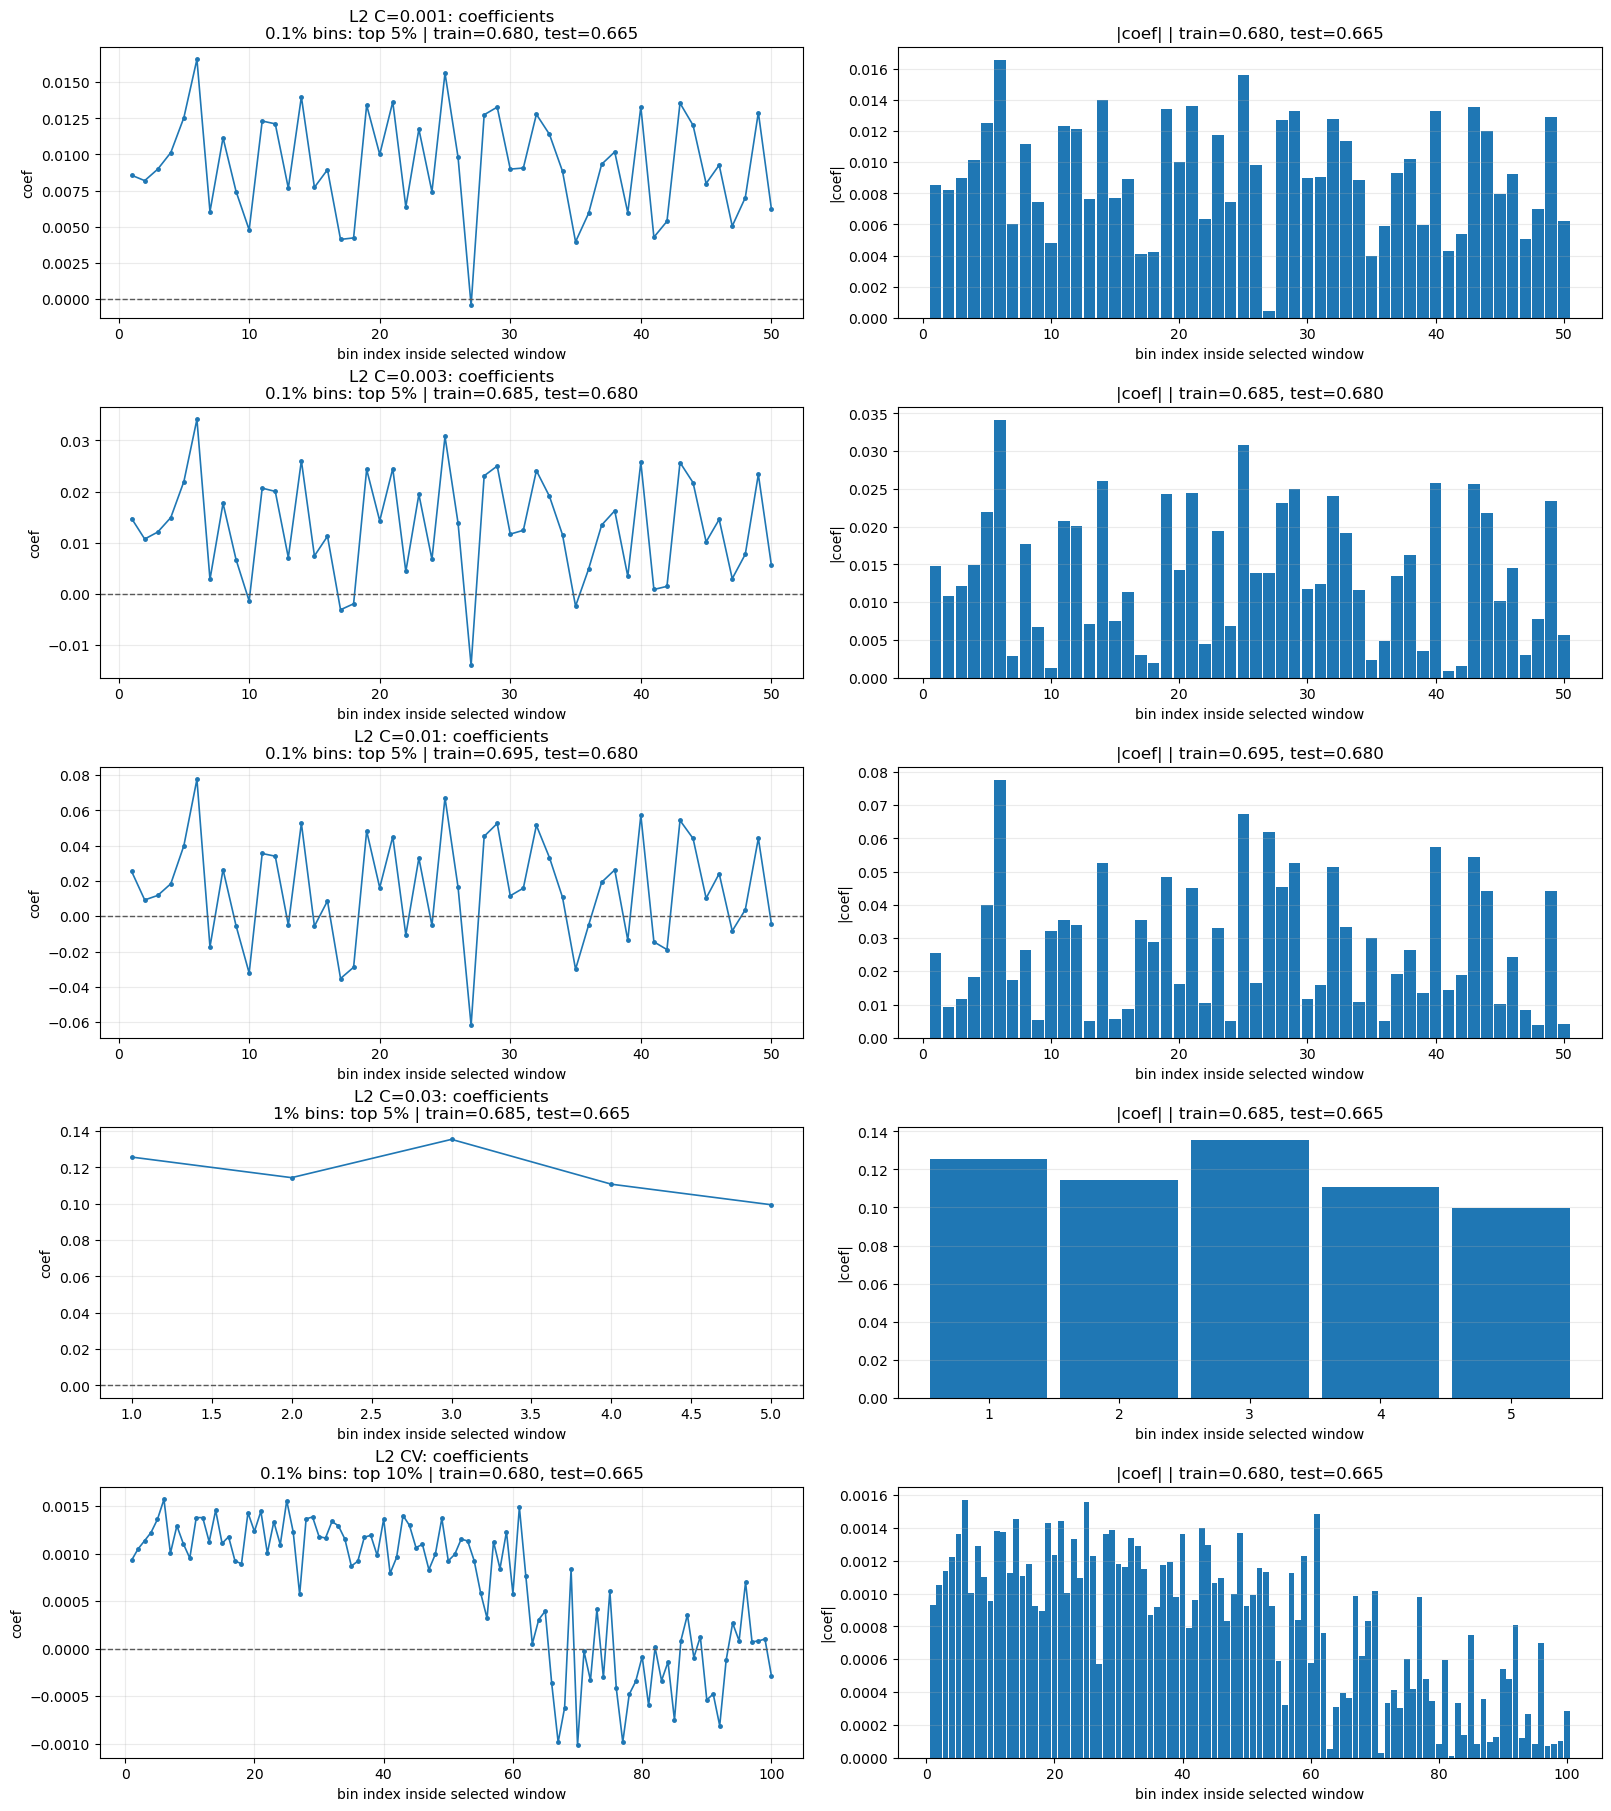

,feature_idx,coef,abs_coef
5,6,0.034126,0.034126
24,25,0.030783,0.030783
13,14,0.026062,0.026062
39,40,0.025741,0.025741
42,43,0.025701,0.025701
28,29,0.025021,0.025021
20,21,0.024521,0.024521
18,19,0.024353,0.024353
31,32,0.024119,0.024119
48,49,0.023378,0.023378


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from patch_success_analysis import bin_metrics

force_bin_granularity_recompute = False
bin_granularity_result = bin_metrics.compute_or_load_bin_granularity_analysis(
    exp,
    rows_df,
    force=force_bin_granularity_recompute,
)

bin_logreg_df = bin_granularity_result["bin_logreg_df"]
manual_01_df = bin_granularity_result["manual_01_df"]
method_compare_df = bin_granularity_result["method_compare_df"]
overall_val_df = bin_granularity_result["overall_val_df"]
runs = bin_granularity_result["runs"]
feature_sets = [(name, None) for name in bin_granularity_result["feature_set_names"]]
strong_cs = bin_granularity_result["strong_cs"]

print(f"bin granularity cache: {bin_granularity_result['cache_path']}")
print(f"loaded_from_cache={bin_granularity_result['loaded_from_cache']}")
display(bin_logreg_df.sort_values(['val_acc', 'val_auc'], ascending=False))

def _set_accuracy_ylim(ax, values, *, bottom_pad=0.025, top_pad=0.045):
    arr = np.asarray(values, dtype='float64').reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        ax.set_ylim(0.0, 1.0)
        return
    lo = float(arr.min())
    hi = float(arr.max())
    span = max(hi - lo, 0.02)
    lower = max(0.0, lo - max(float(bottom_pad), 0.15 * span))
    upper = min(1.0, hi + max(float(top_pad), 0.20 * span))
    if upper - lower < 0.08:
        extra = (0.08 - (upper - lower)) / 2.0
        lower = max(0.0, lower - extra)
        upper = min(1.0, upper + extra)
    ax.set_ylim(lower, upper)

top10_overall_val = overall_val_df.head(10).copy()
display(top10_overall_val[['method', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc']])

fig, ax = plt.subplots(figsize=(14, 5.8), constrained_layout=True)
x = np.arange(len(top10_overall_val))
train_bars = ax.bar(x - 0.18, top10_overall_val['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, top10_overall_val['val_acc'], width=0.36, label='val acc', color='#4C78A8')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
labels = [
    f"{method}\n{source}" if len(str(method)) < 55 else f"{str(method)[:52]}...\n{source}"
    for method, source in zip(top10_overall_val['method'], top10_overall_val['source'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
_set_accuracy_ylim(ax, top10_overall_val[['train_acc', 'val_acc']].to_numpy())
ax.set_title('Top-10 overall metrics by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

display(method_compare_df[['method', 'weights', 'train_acc', 'val_acc', 'val_auc', 'kind']])
fig, ax = plt.subplots(figsize=(max(15, 0.75 * len(method_compare_df)), 6.4), constrained_layout=True)
x = np.arange(len(method_compare_df))
color_by_kind = {'manual': '#4C78A8', 'manual_0.1%': '#F58518', 'learned': '#B279A2'}
colors = [color_by_kind.get(kind, '#4C78A8') for kind in method_compare_df['kind']]
train_bars = ax.bar(x - 0.18, method_compare_df['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, method_compare_df['val_acc'], width=0.36, label='val acc', color=colors)
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
labels = [
    f"{method}\n{weights}" if weights and weights != 'learned' else f"{method}\n{weights}"
    for method, weights in zip(method_compare_df['method'], method_compare_df['weights'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
_set_accuracy_ylim(ax, method_compare_df[['train_acc', 'val_acc']].to_numpy())
ax.set_title('Manual top-k / 0.1% weighted metrics vs best learned model, sorted by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

display(manual_01_df[['method', 'cutoff_percent', 'weight_family', 'n_bins', 'weights', 'train_acc', 'val_acc', 'val_auc']])
fig, ax = plt.subplots(figsize=(15, 5.8), constrained_layout=True)
x = np.arange(len(manual_01_df))
train_bars = ax.bar(x - 0.18, manual_01_df['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, manual_01_df['val_acc'], width=0.36, label='val acc', color='#4C78A8')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(manual_01_df['method'], rotation=35, ha='right')
_set_accuracy_ylim(ax, manual_01_df[['train_acc', 'val_acc']].to_numpy())
ax.set_title('0.1% bin manual weights, sorted by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
for ax, cutoff_percent, n_bins in [(axes[0], 5, 50), (axes[1], 10, 100)]:
    for family in ['flat', 'linear', 'reciprocal', 'sqrt_reciprocal', 'exp']:
        ax.plot(np.arange(1, n_bins + 1), bin_metrics.manual_weight_vector(n_bins, family), label=family)
    ax.set_title(f'0.1% bin weights up to top{cutoff_percent}%')
    ax.set_xlabel('0.1% bin index')
    ax.set_ylabel('weight')
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

plot_df = bin_logreg_df.copy()
plot_df['feature_set'] = plot_df['variant'].str.split(' / ').str[0]
plot_df['regularization'] = plot_df['variant'].str.split(' / ').str[1]
plot_df['model_label'] = plot_df['variant'].str.replace(' / ', '\n', regex=False)
reg_order = ['L2 CV'] + [f'L2 C={c:g}' for c in strong_cs]

top5_models = bin_logreg_df.sort_values(['val_acc', 'val_auc'], ascending=False).head(5).copy()
top5_models['label'] = top5_models['variant'].str.replace(' / ', '\n', regex=False)
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
x = np.arange(len(top5_models))
train_bars = ax.bar(x - 0.18, top5_models['train_acc'], width=0.36, label='train acc')
val_bars = ax.bar(x + 0.18, top5_models['val_acc'], width=0.36, label='val acc')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(top5_models['label'], rotation=0, ha='center')
_set_accuracy_ylim(ax, top5_models[['train_acc', 'val_acc']].to_numpy())
ax.set_title('Top-5 learned bin-weight models by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

all_plot = plot_df.sort_values(['val_acc', 'val_auc'], ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(max(18, 0.62 * len(all_plot)), 6.5), constrained_layout=True)
x = np.arange(len(all_plot))
train_bars = ax.bar(x - 0.18, all_plot['train_acc'], width=0.36, label='train acc')
val_bars = ax.bar(x + 0.18, all_plot['val_acc'], width=0.36, label='val acc')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(all_plot['model_label'], rotation=60, ha='right', fontsize=8)
_set_accuracy_ylim(ax, all_plot[['train_acc', 'val_acc']].to_numpy())
ax.set_title('All learned bin-weight models: train/test accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

fig, axes = plt.subplots(len(reg_order), 1, figsize=(17, 4.2 * len(reg_order)), constrained_layout=True)
if len(reg_order) == 1:
    axes = [axes]
for ax, reg_name in zip(axes, reg_order):
    sub = plot_df[plot_df['regularization'] == reg_name].set_index('feature_set').loc[[name for name, _ in feature_sets]]
    x = np.arange(len(sub))
    train_bars = ax.bar(x - 0.18, sub['train_acc'], width=0.36, label='train acc')
    val_bars = ax.bar(x + 0.18, sub['val_acc'], width=0.36, label='val acc')
    for bars in (train_bars, val_bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=25, ha='right')
    _set_accuracy_ylim(ax, sub[['train_acc', 'val_acc']].to_numpy())
    ax.set_title(f"{reg_name}: train/test accuracy")
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='upper right')
plt.show()

best_by_reg = (
    plot_df.sort_values(['regularization', 'val_acc', 'val_auc'], ascending=[True, False, False])
    .groupby('regularization', as_index=False)
    .first()
)
display(best_by_reg[['regularization', 'variant', 'n_features', 'C', 'train_acc', 'val_acc', 'train_auc', 'val_auc']])

fig, axes = plt.subplots(len(best_by_reg), 2, figsize=(16, 3.6 * len(best_by_reg)), constrained_layout=True)
if len(best_by_reg) == 1:
    axes = np.array([axes])
for row_idx, (_, best_row) in enumerate(best_by_reg.iterrows()):
    run = next(item for item in runs if item['variant'] == best_row['variant'])
    coef = np.asarray(run['coef'], dtype='float64')
    feature_idx = np.arange(1, coef.size + 1)
    axes[row_idx, 0].plot(feature_idx, coef, marker='o', linewidth=1.2, markersize=2.5)
    axes[row_idx, 0].axhline(0, color='0.35', linestyle='--', linewidth=1)
    axes[row_idx, 0].set_title(
        f"{best_row['regularization']}: coefficients\n"
        f"{best_row['feature_set']} | train={best_row['train_acc']:.3f}, test={best_row['val_acc']:.3f}"
    )
    axes[row_idx, 0].set_xlabel('bin index inside selected window')
    axes[row_idx, 0].set_ylabel('coef')
    axes[row_idx, 0].grid(alpha=0.25)
    axes[row_idx, 1].bar(feature_idx, np.abs(coef), width=0.9)
    axes[row_idx, 1].set_title(f"|coef| | train={best_row['train_acc']:.3f}, test={best_row['val_acc']:.3f}")
    axes[row_idx, 1].set_xlabel('bin index inside selected window')
    axes[row_idx, 1].set_ylabel('|coef|')
    axes[row_idx, 1].grid(axis='y', alpha=0.25)
plt.show()

best_run = sorted(runs, key=lambda row: (row['val_acc'], row['val_auc']), reverse=True)[0]
display(pd.DataFrame({
    'feature_idx': np.arange(1, len(best_run['coef']) + 1),
    'coef': best_run['coef'],
}).assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False).head(25))

### Вывод по обученным весам

Если качество растёт только на train/all, но не на validation, значит более свободные веса просто подбирают форму под конкретный набор. Поэтому для финальной метрики нам важнее варианты, где `val_acc` не проседает и веса остаются гладкими/объяснимыми.


### Минимальная диагностика signed product

Оставляем только три проверки, достаточные для вывода, почему `importance * delta` проигрывает rank/top-k метрикам: концентрация product mass в первых рангах, слабость signed-компоненты и асимметрия гипотезы для `A > 0` / `A < 0`.


In [6]:
import hashlib
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from patch_success_analysis.activations import capture_activations, compute_layer_deltas, patch_mask_on_feature_grid
from patch_success_analysis.attributions import compute_layer_ig_attribution
from patch_success_analysis.yolo import get_module_by_name

# Keep this modest: each example requires SegmentIG[0;0.1] and layer-delta recomputation.
diagnostic_max_per_class = 20
diagnostic_n_bins = 100
diagnostic_scatter_points_per_example = 1500
diagnostic_compute_patched_attribution = True
rng = np.random.default_rng(17)

cache = exp.get_cache()
diagnostic_examples = cache.successes[:diagnostic_max_per_class] + cache.failures[:diagnostic_max_per_class]
diagnostic_cache_force = False
diagnostic_cache_payload = {
    'attack_cache_key': cache.cache_key,
    'paths': [item.path for item in diagnostic_examples],
    'target_layer': config.target_layer,
    'detect_layer': config.detect_layer,
    'target_mode': config.target_mode,
    'n_steps': int(config.n_steps),
    'alpha_batch_size': int(config.alpha_batch_size),
    'diagnostic_max_per_class': int(diagnostic_max_per_class),
    'diagnostic_n_bins': int(diagnostic_n_bins),
    'diagnostic_scatter_points_per_example': int(diagnostic_scatter_points_per_example),
    'diagnostic_compute_patched_attribution': bool(diagnostic_compute_patched_attribution),
    'method_version': 2,
}
diagnostic_cache_key = hashlib.sha256(
    json.dumps(diagnostic_cache_payload, sort_keys=True, ensure_ascii=True).encode('utf-8')
).hexdigest()[:16]
diagnostic_cache_path = exp.derived_cache_dir / f'signed_product_diagnostics_{diagnostic_cache_key}.pkl'

if diagnostic_cache_path.exists() and not diagnostic_cache_force:
    with diagnostic_cache_path.open('rb') as f:
        diagnostic_cached = pickle.load(f)
    diag_scalar_df = diagnostic_cached['diag_scalar_df']
    diag_bin_df = diagnostic_cached['diag_bin_df']
    diag_scatter_df = diagnostic_cached['diag_scatter_df']
    diag_channel_df = diagnostic_cached['diag_channel_df']
    diag_stability_bin_df = diagnostic_cached['diag_stability_bin_df']
    print(f'loaded signed-product diagnostics from {diagnostic_cache_path}')
else:
    _yolo, model = exp.load_model()
    layer_name = config.target_layer
    layer = get_module_by_name(model, layer_name)

    def _chw_np(tensor):
        arr = tensor.detach().cpu().numpy()
        if arr.ndim == 4:
            arr = arr[0]
        if arr.ndim != 3:
            raise ValueError(f'Expected [C,H,W] or [1,C,H,W], got {arr.shape}')
        return arr.astype('float64', copy=False)

    def _rank_bins(values, importance, *, n_bins=100, reducer='mean', weights=None):
        values = np.asarray(values, dtype='float64').reshape(-1)
        importance = np.asarray(importance, dtype='float64').reshape(-1)
        n = min(values.size, importance.size)
        values, importance = values[:n], importance[:n]
        if weights is not None:
            weights = np.asarray(weights, dtype='float64').reshape(-1)[:n]
        order = np.argsort(-np.abs(importance), kind='stable')
        bin_ids = np.floor(np.arange(n, dtype='float64') * n_bins / n).astype(int)
        bin_ids = np.clip(bin_ids, 0, n_bins - 1)
        ranked_values = values[order]
        if reducer == 'sum':
            return np.bincount(bin_ids, weights=ranked_values, minlength=n_bins).astype('float64')
        if reducer == 'weighted_mean':
            ranked_weights = weights[order]
            num = np.bincount(bin_ids, weights=ranked_values * ranked_weights, minlength=n_bins).astype('float64')
            den = np.bincount(bin_ids, weights=ranked_weights, minlength=n_bins).astype('float64')
            return num / np.maximum(den, 1e-12)
        sums = np.bincount(bin_ids, weights=ranked_values, minlength=n_bins).astype('float64')
        counts = np.bincount(bin_ids, minlength=n_bins).astype('float64')
        return sums / np.maximum(counts, 1.0)

    def _weighted_mean(values, weights):
        values = np.asarray(values, dtype='float64')
        weights = np.asarray(weights, dtype='float64')
        return float(np.sum(values * weights) / (np.sum(weights) + 1e-12))

    diag_scalar_rows = []
    diag_bin_rows = []
    diag_scatter_rows = []
    diag_channel_rows = []
    diag_stability_bin_rows = []

    for ex_idx, example in enumerate(diagnostic_examples, start=1):
        print(f'[{ex_idx}/{len(diagnostic_examples)}] {example.path} success={example.success}')
        ctx = exp._context_for_example(example, image_variant='clean')
        clean_pack = exp._preprocess(ctx['clean_lb'])
        patched_pack = exp._preprocess(ctx['patched_lb'])
        deltas = compute_layer_deltas(model, clean_pack['im'], patched_pack['im'], [layer_name])
        delta_chw = _chw_np(deltas[layer_name].delta)
        clean_act_chw = _chw_np(capture_activations(model, clean_pack['im'], [layer_name])[layer_name])
        seg_clean = compute_layer_ig_attribution(
            model,
            ctx['inputs'],
            ctx['baselines'],
            target_fn=ctx['target_fn'],
            layer=layer,
            layer_name=layer_name,
            method='SegmentIG[0;0.1]',
            n_steps=int(config.n_steps),
            alpha_batch_size=int(config.alpha_batch_size),
            segment_start=0.0,
            segment_end=0.1,
        )
        a_chw = _chw_np(seg_clean.chw())
        if diagnostic_compute_patched_attribution:
            patched_baseline = torch.zeros_like(patched_pack['im'])
            seg_patched = compute_layer_ig_attribution(
                model,
                patched_pack['im'],
                patched_baseline,
                target_fn=ctx['target_fn'],
                layer=layer,
                layer_name=layer_name,
                method='SegmentIG[0;0.1] patched',
                n_steps=int(config.n_steps),
                alpha_batch_size=int(config.alpha_batch_size),
                segment_start=0.0,
                segment_end=0.1,
            )
            a_patched_chw = _chw_np(seg_patched.chw())
        else:
            a_patched_chw = np.full_like(a_chw, np.nan)

        d = delta_chw.reshape(-1)
        a = a_chw.reshape(-1)
        clean_act = clean_act_chw.reshape(-1)
        n = min(d.size, a.size)
        d, a, clean_act = d[:n], a[:n], clean_act[:n]
        d_abs = np.abs(d)
        a_abs = np.abs(a)
        a_norm = a / (np.max(a_abs) + 1e-12)
        signed = -a_norm * d
        unsigned = np.abs(a_norm) * d_abs
        correct = signed > 0
        pos = a > 0
        neg = a < 0
        rel_delta = d / (np.abs(clean_act) + 1e-6)
        signed_rel = -a_norm * rel_delta

        c, h, w = delta_chw.shape
        roi_hw = patch_mask_on_feature_grid(example.patch_bbox_lb, grid_hw=(h, w), imgsz=int(config.attack.imgsz)).reshape(-1)
        roi = np.tile(roi_hw, c)[:n]

        correct_mass = float(unsigned[correct].sum())
        wrong_mass = float(unsigned[~correct].sum())
        total_mass = correct_mass + wrong_mass + 1e-12
        row_base = {
            'path': example.path,
            'success': bool(example.success),
            'drop': float(example.drop),
    }
        diag_scalar_rows.append({
            **row_base,
            'signed_product_mean': float(np.mean(signed)),
            'signed_product_sum_norm_delta': float(np.sum(signed) / (np.sum(d_abs) + 1e-12)),
            'unsigned_product_sum_norm_delta': float(np.sum(unsigned) / (np.sum(d_abs) + 1e-12)),
            'correct_sign_fraction': float(np.mean(correct)),
            'correct_mass': correct_mass,
            'wrong_mass': wrong_mass,
            'correct_minus_wrong_norm': float((correct_mass - wrong_mass) / total_mass),
            'correct_mass_ratio': float(correct_mass / total_mass),
            'pos_importance_correct_fraction': float(np.mean(d[pos] < 0)) if np.any(pos) else np.nan,
            'neg_importance_correct_fraction': float(np.mean(d[neg] > 0)) if np.any(neg) else np.nan,
            'pos_importance_mean_delta': float(np.mean(d[pos])) if np.any(pos) else np.nan,
            'neg_importance_mean_delta': float(np.mean(d[neg])) if np.any(neg) else np.nan,
            'signed_relative_delta_sum_norm': float(np.sum(signed_rel) / (np.sum(np.abs(rel_delta)) + 1e-12)),
            'roi_signed_product_sum': float(np.sum(signed[roi])),
            'outside_roi_signed_product_sum': float(np.sum(signed[~roi])),
            'roi_correct_mass_ratio': float(np.sum(unsigned[roi & correct]) / (np.sum(unsigned[roi]) + 1e-12)) if np.any(roi) else np.nan,
            'outside_roi_correct_mass_ratio': float(np.sum(unsigned[(~roi) & correct]) / (np.sum(unsigned[~roi]) + 1e-12)) if np.any(~roi) else np.nan,
            'clean_patched_importance_sign_agreement': float(np.mean(np.sign(a) == np.sign(a_patched_chw.reshape(-1)[:n]))) if diagnostic_compute_patched_attribution else np.nan,
            'clean_patched_importance_weighted_sign_agreement': _weighted_mean(np.sign(a) == np.sign(a_patched_chw.reshape(-1)[:n]), a_abs) if diagnostic_compute_patched_attribution else np.nan,
    })

        bin_signed_sum = _rank_bins(signed, a, n_bins=diagnostic_n_bins, reducer='sum') / (np.sum(d_abs) + 1e-12)
        bin_unsigned_sum = _rank_bins(unsigned, a, n_bins=diagnostic_n_bins, reducer='sum') / (np.sum(d_abs) + 1e-12)
        bin_correct_frac = _rank_bins(correct.astype(float), a, n_bins=diagnostic_n_bins, reducer='weighted_mean', weights=unsigned)
        bin_signed_mean = _rank_bins(signed, a, n_bins=diagnostic_n_bins, reducer='mean')
        for bin_idx in range(diagnostic_n_bins):
            diag_bin_rows.append({
                **row_base,
                'bin': bin_idx + 1,
                'rank_percent_from': bin_idx,
                'rank_percent_to': bin_idx + 1,
                'signed_sum_norm_delta': float(bin_signed_sum[bin_idx]),
                'unsigned_sum_norm_delta': float(bin_unsigned_sum[bin_idx]),
                'correct_mass_ratio': float(bin_correct_frac[bin_idx]),
                'signed_mean': float(bin_signed_mean[bin_idx]),
            })

        if diagnostic_compute_patched_attribution:
            a_p = a_patched_chw.reshape(-1)[:n]
            sign_same = (np.sign(a) == np.sign(a_p)).astype(float)
            stability = _rank_bins(sign_same, a, n_bins=diagnostic_n_bins, reducer='weighted_mean', weights=a_abs)
            for bin_idx in range(diagnostic_n_bins):
                diag_stability_bin_rows.append({**row_base, 'bin': bin_idx + 1, 'weighted_sign_agreement': float(stability[bin_idx])})

        sample_n = min(diagnostic_scatter_points_per_example, n)
        sample_idx = rng.choice(n, size=sample_n, replace=False)
        diag_scatter_rows.extend({
            **row_base,
            'importance': float(a[idx]),
            'delta': float(d[idx]),
            'signed_product': float(signed[idx]),
            'unsigned_product': float(unsigned[idx]),
            'correct_sign': bool(correct[idx]),
    } for idx in sample_idx)

        channel_signed = signed.reshape(c, h, w).sum(axis=(1, 2)) / (np.sum(d_abs) + 1e-12)
        channel_unsigned = unsigned.reshape(c, h, w).sum(axis=(1, 2)) / (np.sum(d_abs) + 1e-12)
        channel_correct = np.array([
            np.sum(unsigned.reshape(c, h, w)[ch][correct.reshape(c, h, w)[ch]]) / (np.sum(unsigned.reshape(c, h, w)[ch]) + 1e-12)
            for ch in range(c)
        ])
        for ch in range(c):
            diag_channel_rows.append({
                **row_base,
                'channel': ch,
                'signed_sum_norm_delta': float(channel_signed[ch]),
                'unsigned_sum_norm_delta': float(channel_unsigned[ch]),
                'correct_mass_ratio': float(channel_correct[ch]),
            })

    diag_scalar_df = pd.DataFrame(diag_scalar_rows)
    diag_bin_df = pd.DataFrame(diag_bin_rows)
    diag_scatter_df = pd.DataFrame(diag_scatter_rows)
    diag_channel_df = pd.DataFrame(diag_channel_rows)
    diag_stability_bin_df = pd.DataFrame(diag_stability_bin_rows)

    diagnostic_cached = {
        'diag_scalar_df': diag_scalar_df,
        'diag_bin_df': diag_bin_df,
        'diag_scatter_df': diag_scatter_df,
        'diag_channel_df': diag_channel_df,
        'diag_stability_bin_df': diag_stability_bin_df,
        'payload': diagnostic_cache_payload,
    }
    with diagnostic_cache_path.open('wb') as f:
        pickle.dump(diagnostic_cached, f)
    print(f'saved signed-product diagnostics to {diagnostic_cache_path}')

print({
    'examples': len(diag_scalar_df),
    'scatter_points': len(diag_scatter_df),
    'bins': len(diag_bin_df),
    'channels': len(diag_channel_df),
    'cache_path': str(diagnostic_cache_path),
})

loaded signed-product diagnostics from new_experiments/outputs/patch_success_analysis/cache/signed_product_diagnostics_a14f4616b394f35d.pkl
{'examples': 40, 'scatter_points': 60000, 'bins': 4000, 'channels': 20480, 'cache_path': 'new_experiments/outputs/patch_success_analysis/cache/signed_product_diagnostics_a14f4616b394f35d.pkl'}


### 1. Зачем: проверить, является ли product действительно soft-метрикой

Если `|A| * |Δ|` почти целиком сосредоточен в первых 1-5% рангов, то произведение не использует “мягко” все бины, а превращается в очень узкую top-метрику, чувствительную к нескольким экстремальным attribution-точкам.


success,fail_mean,success_mean
top_bins,,
1,0.845475,0.852127
2,0.940144,0.942199
3,0.976513,0.978143
5,0.998396,0.998492
10,1.000000,1.000000
25,1.000000,1.000000
50,1.000000,1.000000
100,1.000000,1.000000


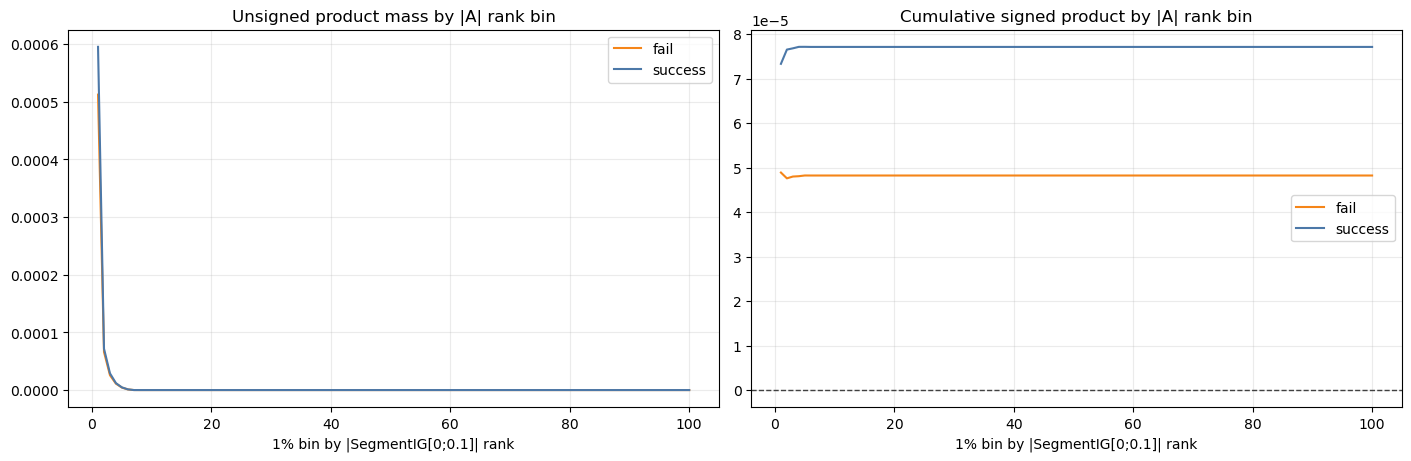

In [7]:
mass = diag_bin_df.pivot_table(index=['path', 'success'], columns='bin', values='unsigned_sum_norm_delta').fillna(0).sort_index(axis=1)
total_mass = mass.sum(axis=1).replace(0, np.nan)
rows = []
for k in [1, 2, 3, 5, 10, 25, 50, 100]:
    frac = (mass.loc[:, :k].sum(axis=1) / total_mass).reset_index(name='mass_fraction')
    summary = frac.groupby('success')['mass_fraction'].agg(['mean', 'std']).reset_index()
    summary['top_bins'] = k
    rows.append(summary)
product_mass_concentration = pd.concat(rows, ignore_index=True)
display(product_mass_concentration.pivot(index='top_bins', columns='success', values='mean').rename(columns={False: 'fail_mean', True: 'success_mean'}))

bin_mean = diag_bin_df.groupby(['success', 'bin'])[['unsigned_sum_norm_delta', 'signed_sum_norm_delta']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for success, label, color in [(False, 'fail', '#F58518'), (True, 'success', '#4C78A8')]:
    sub = bin_mean[bin_mean['success'] == success]
    axes[0].plot(sub['bin'], sub['unsigned_sum_norm_delta'], label=label, color=color)
    axes[1].plot(sub['bin'], sub['signed_sum_norm_delta'].cumsum(), label=label, color=color)
axes[0].set_title('Unsigned product mass by |A| rank bin')
axes[1].set_title('Cumulative signed product by |A| rank bin')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
for ax in axes:
    ax.set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

### 1b. Зачем: посмотреть отдельно на оба множителя product-метрик

Для unsigned product множители — это `|A|` и `|Δ|`. Для signed product — это `-A` и `Δ`, потому что сама метрика считает `(-A) * Δ`. Здесь смотрим, где по рангу `|A|` концентрируются сами множители и где концентрируется их произведение.


abs_importance_mass           abs_delta_mass            \
success                 fail   success           fail   success   
top_bins                                                          
1                   0.701312  0.783143       0.015166  0.017487   
2                   0.815676  0.908173       0.026840  0.030761   
3                   0.865259  0.962319       0.037349  0.042852   
5                   0.897399  0.997184       0.056967  0.063801   
10                  0.900000  1.000000       0.101222  0.108089   
25                  0.900000  1.000000       0.253385  0.257413   
50                  0.900000  1.000000       0.510315  0.511535   
100                 0.900000  1.000000       1.000000  1.000000   

         unsigned_product_mass           abs_signed_product_mass            
success                   fail   success                    fail   success  
top_bins                                                                    
1                     0.760918  0.852101                0.760918  0.852101  
2                     0.846129  0.942203                0.846129  0.942203  
3                     0.878862  0.978145                0.878862  0.978145  
5                     0.898556  0.998492                0.898556  0.998492  
10                    0.900000  1.000000                0.900000  1.000000  
25                    0.900000  1.000000                0.900000  1.000000  
50                    0.900000  1.000000                0.900000  1.000000  
100                   0.900000  1.000000                0.900000  1.000000

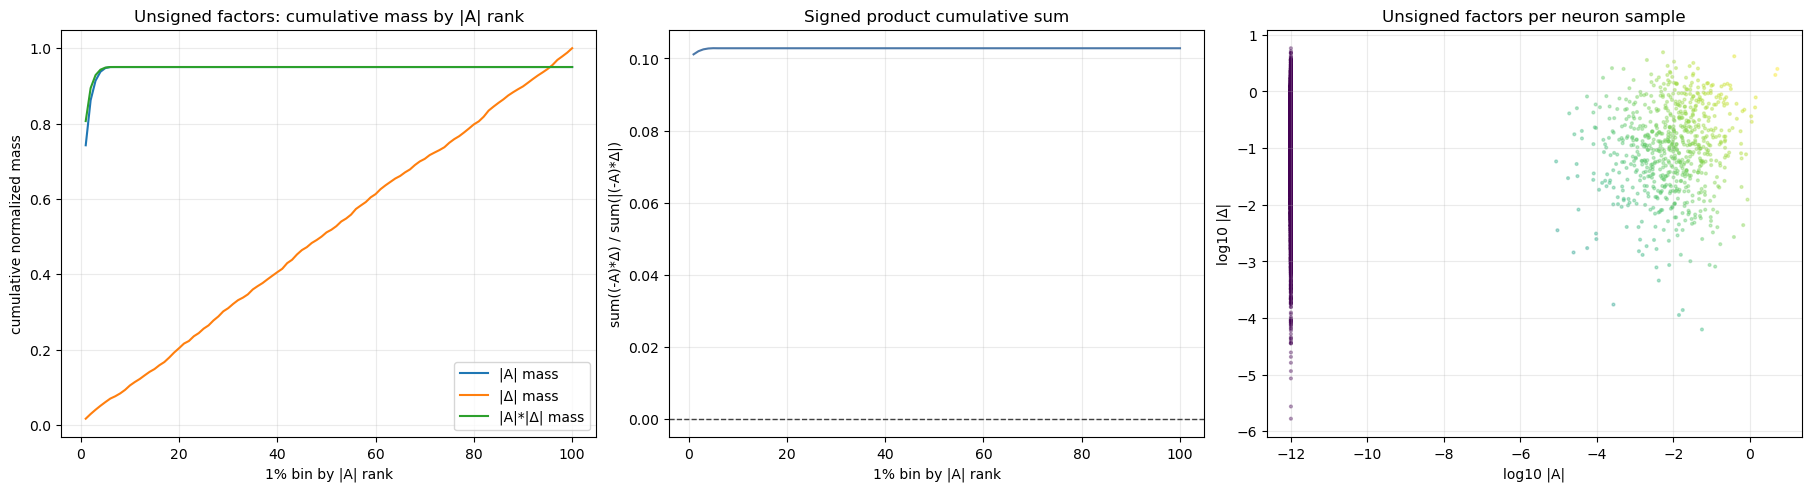

,mean_signed_importance_factor,mean_signed_delta_factor,signed_product_sum_norm_abs
success,,,
fail,-0.000374,-0.011910,0.000801
success,-0.000459,-0.010223,0.001256


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from patch_success_analysis.notebook_setup import resolve_existing_path
factor_examples_per_class = 20
factor_n_bins = 100
factor_examples = pd.concat([
    rows_df[rows_df['success'] == True].head(factor_examples_per_class),
    rows_df[rows_df['success'] == False].head(factor_examples_per_class),
], ignore_index=True)

def _bin_ids_by_abs_importance(importance, n_bins):
    order = np.argsort(-np.abs(importance), kind='mergesort')
    bin_ids = np.empty(order.size, dtype=np.int32)
    for bin_idx, idx in enumerate(np.array_split(order, n_bins)):
        bin_ids[idx] = bin_idx + 1
    return bin_ids

factor_rows = []
scatter_rows = []
rng = np.random.default_rng(17)
for _, row in factor_examples.iterrows():
    with np.load(resolve_existing_path(row['layer_maps_cache_path']), allow_pickle=False) as data:
        a = data['segmentig_chw'].astype('float32', copy=False).reshape(-1)
        d = data['delta_chw'].astype('float32', copy=False).reshape(-1)
    n = min(a.size, d.size)
    a = a[:n]
    d = d[:n]
    a_abs = np.abs(a)
    d_abs = np.abs(d)
    unsigned = a_abs * d_abs
    signed = (-a) * d
    bin_ids = _bin_ids_by_abs_importance(a, factor_n_bins)
    denom_a = a_abs.sum() + 1e-12
    denom_d = d_abs.sum() + 1e-12
    denom_unsigned = unsigned.sum() + 1e-12
    denom_signed_abs = np.abs(signed).sum() + 1e-12
    for bin_idx in range(1, factor_n_bins + 1):
        mask = bin_ids == bin_idx
        factor_rows.append({
            'path': row['path'],
            'success': bool(row['success']),
            'bin': bin_idx,
            'abs_importance_mass': float(a_abs[mask].sum() / denom_a),
            'abs_delta_mass': float(d_abs[mask].sum() / denom_d),
            'unsigned_product_mass': float(unsigned[mask].sum() / denom_unsigned),
            'abs_signed_product_mass': float(np.abs(signed[mask]).sum() / denom_signed_abs),
            'signed_product_sum_norm_abs': float(signed[mask].sum() / denom_signed_abs),
            'mean_signed_importance_factor': float(np.mean((-a)[mask])),
            'mean_signed_delta_factor': float(np.mean(d[mask])),
        })
    sample_n = min(1500, n)
    sample_idx = rng.choice(n, size=sample_n, replace=False)
    scatter_rows.extend({
        'success': bool(row['success']),
        'abs_importance': float(a_abs[idx]),
        'abs_delta': float(d_abs[idx]),
        'signed_importance_factor': float(-a[idx]),
        'signed_delta_factor': float(d[idx]),
        'unsigned_product': float(unsigned[idx]),
        'signed_product': float(signed[idx]),
    } for idx in sample_idx)

factor_bin_df = pd.DataFrame(factor_rows)
factor_scatter_df = pd.DataFrame(scatter_rows)

top_rows = []
for k in [1, 2, 3, 5, 10, 25, 50, 100]:
    sub = factor_bin_df[factor_bin_df['bin'] <= k]
    agg = sub.groupby(['path', 'success'])[[
        'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
    ]].sum().reset_index()
    summary = agg.groupby('success')[[
        'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
    ]].mean().reset_index()
    summary['top_bins'] = k
    top_rows.append(summary)
factor_concentration = pd.concat(top_rows, ignore_index=True)
display(factor_concentration.pivot(index='top_bins', columns='success', values=[
    'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
]).rename(columns={False: 'fail', True: 'success'}))

factor_mean = factor_bin_df.groupby('bin')[[
    'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass', 'signed_product_sum_norm_abs'
]].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
axes[0].plot(factor_mean['bin'], factor_mean['abs_importance_mass'].cumsum(), label='|A| mass')
axes[0].plot(factor_mean['bin'], factor_mean['abs_delta_mass'].cumsum(), label='|Δ| mass')
axes[0].plot(factor_mean['bin'], factor_mean['unsigned_product_mass'].cumsum(), label='|A|*|Δ| mass')
axes[0].set_title('Unsigned factors: cumulative mass by |A| rank')
axes[0].set_xlabel('1% bin by |A| rank')
axes[0].set_ylabel('cumulative normalized mass')
axes[0].legend()

axes[1].plot(factor_mean['bin'], factor_mean['signed_product_sum_norm_abs'].cumsum(), color='#4C78A8')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
axes[1].set_title('Signed product cumulative sum')
axes[1].set_xlabel('1% bin by |A| rank')
axes[1].set_ylabel('sum((-A)*Δ) / sum(|(-A)*Δ|)')

plot_sample = factor_scatter_df.sample(min(12000, len(factor_scatter_df)), random_state=17)
axes[2].scatter(
    np.log10(plot_sample['abs_importance'] + 1e-12),
    np.log10(plot_sample['abs_delta'] + 1e-12),
    c=np.log10(plot_sample['unsigned_product'].abs() + 1e-18),
    s=4, alpha=0.35, cmap='viridis',
)
axes[2].set_title('Unsigned factors per neuron sample')
axes[2].set_xlabel('log10 |A|')
axes[2].set_ylabel('log10 |Δ|')
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

signed_factor_summary = factor_bin_df.groupby('success')[[
    'mean_signed_importance_factor', 'mean_signed_delta_factor', 'signed_product_sum_norm_abs'
]].mean().rename(index={False: 'fail', True: 'success'})
display(signed_factor_summary)


### Вывод 1b

Теперь видно не только сам product, но и его множители. Если `|A| * |Δ|` концентрируется намного быстрее, чем `|A|` и `|Δ|` по отдельности, значит произведение усиливает экстремальные точки: оно выбирает места, где одновременно большой attribution и большая дельта. Для signed-варианта дополнительно видно, что знак зависит от согласованности `-A` и `Δ`, а этот эффект слабее и шумнее простой концентрации magnitude.


### Вывод 1

На текущем диагностическом кэше `|A| * |Δ|` почти полностью сидит в первых рангах: top-1% даёт примерно 82-86% product mass, top-2% — 93-95%, top-5% — около 99.8%. Поэтому произведение важности на дельту не является хорошей soft-версией top-k: оно слишком сильно доверяет экстремальным значениям SegmentIG.


### 2. Зачем: отделить magnitude-сигнал от signed-сигнала

Unsigned product отвечает на вопрос “попала ли дельта в большие `|A|`”, а signed product дополнительно требует правильного направления `-A * Δ > 0`. Если unsigned работает лучше signed, проблема именно в добавлении знака.


signed_product_sum_norm_delta            \
                                 mean       std   
success                                           
fail                         0.000048  0.000065   
success                      0.000077  0.000085   

        unsigned_product_sum_norm_delta           correct_mass_ratio  \
                                   mean       std               mean   
success                                                                
fail                           0.000621  0.000419           0.490057   
success                        0.000714  0.000449           0.562773   

                  correct_minus_wrong_norm            
              std                     mean       std  
success                                               
fail     0.175416                 0.080114  0.107147  
success  0.062230                 0.125547  0.124460

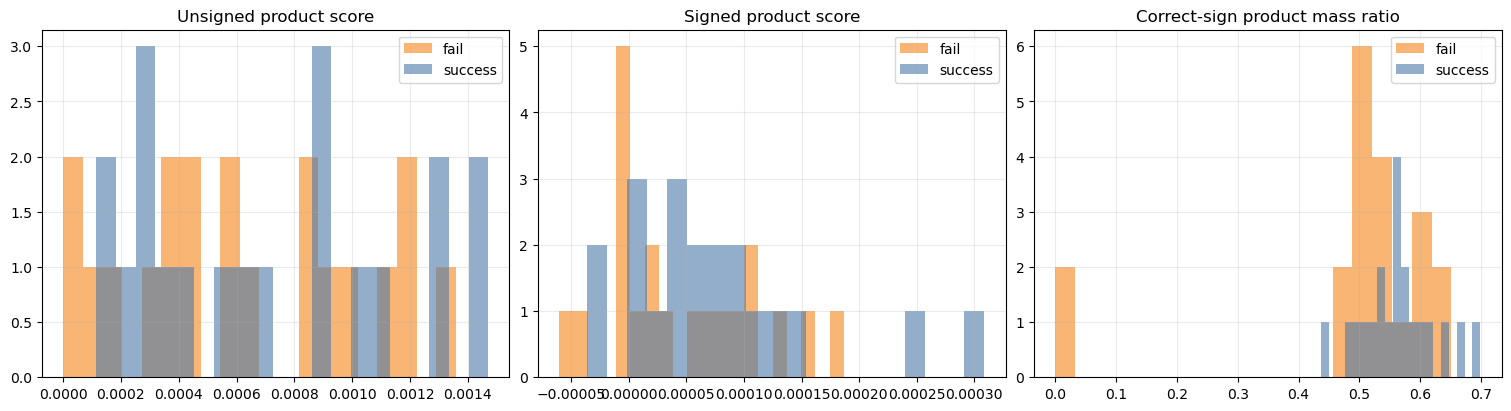

,metric,roc_auc,best_accuracy,best_direction
7,segmentig_delta_energy_in_importance_top,0.667132,0.639568,1
8,segmentig_delta_importance_product_signed,0.568334,0.558803,1
9,segmentig_delta_importance_product_unsigned,0.563249,0.550301,1


In [9]:
decomp_cols = [
    'signed_product_sum_norm_delta',
    'unsigned_product_sum_norm_delta',
    'correct_mass_ratio',
    'correct_minus_wrong_norm',
]
decomp_summary = diag_scalar_df.groupby('success')[decomp_cols].agg(['mean', 'std']).rename(index={False: 'fail', True: 'success'})
display(decomp_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for success, label, color in [(False, 'fail', '#F58518'), (True, 'success', '#4C78A8')]:
    sub = diag_scalar_df[diag_scalar_df['success'] == success]
    axes[0].hist(sub['unsigned_product_sum_norm_delta'], bins=20, alpha=0.6, label=label, color=color)
    axes[1].hist(sub['signed_product_sum_norm_delta'], bins=20, alpha=0.6, label=label, color=color)
    axes[2].hist(sub['correct_mass_ratio'], bins=20, alpha=0.6, label=label, color=color)
axes[0].set_title('Unsigned product score')
axes[1].set_title('Signed product score')
axes[2].set_title('Correct-sign product mass ratio')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

quality_focus = quality_df[quality_df['metric'].isin([
    'segmentig_delta_importance_product_signed',
    'segmentig_delta_importance_product_unsigned',
    'segmentig_delta_energy_in_importance_top',
])][['metric', 'roc_auc', 'best_accuracy', 'best_direction']]
display(quality_focus)

### Вывод 2

Unsigned product уже заметно слабее top-k, но signed ещё хуже: на полном кэше ROC-AUC примерно 0.750 для unsigned product и 0.716 для signed product против 0.900 у `delta_energy_in_importance_top`. Correct-sign mass у success выше, но разница небольшая: около 0.55 против 0.49. Значит знак добавляет слабый и шумный сигнал.


### 3. Зачем: проверить две половины signed-гипотезы отдельно

Signed-гипотеза требует двух вещей: для `A > 0` дельта должна чаще быть отрицательной, а для `A < 0` — положительной. Если одна половина не выполняется, общий `-A * Δ` размывается.


pos_importance_correct_fraction            \
                                   mean       std   
success                                             
fail                           0.520612  0.038828   
success                        0.526997  0.032721   

        neg_importance_correct_fraction           pos_importance_mean_delta  \
                                   mean       std                      mean   
success                                                                       
fail                           0.479254  0.037781                 -0.015200   
success                        0.477744  0.027184                 -0.032804   

                  neg_importance_mean_delta           
              std                      mean      std  
success                                               
fail     0.042078                 -0.011910  0.04210  
success  0.030945                 -0.020857  0.02516

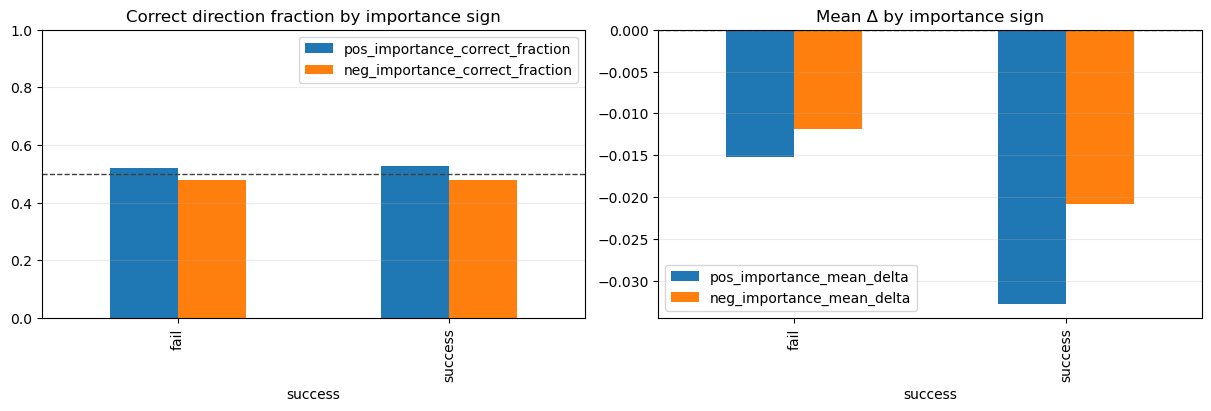

In [10]:
sign_split_cols = [
    'pos_importance_correct_fraction',
    'neg_importance_correct_fraction',
    'pos_importance_mean_delta',
    'neg_importance_mean_delta',
]
sign_split_summary = diag_scalar_df.groupby('success')[sign_split_cols].agg(['mean', 'std']).rename(index={False: 'fail', True: 'success'})
display(sign_split_summary)

plot_summary = diag_scalar_df.groupby('success')[sign_split_cols].mean().rename(index={False: 'fail', True: 'success'})
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_summary[['pos_importance_correct_fraction', 'neg_importance_correct_fraction']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Correct direction fraction by importance sign')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='0.25', linestyle='--', linewidth=1)
plot_summary[['pos_importance_mean_delta', 'neg_importance_mean_delta']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Δ by importance sign')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
for ax in axes:
    ax.grid(axis='y', alpha=0.25)
plt.show()

### Вывод 3

На текущем кэше signed-гипотеза не выполняется симметрично. Для `A > 0` success не чаще даёт правильное направление, чем fail; для `A < 0` есть только небольшой плюс. Поэтому общий signed product смешивает слабые и частично противоречивые эффекты.


## Handcrafted feature selection

Этот блок использует все одиночные scalar-признаки из `sf["rows"]`: handcrafted features из карт `Δ` и `SegmentIG[0;0.1]`, alignment/spread метрики, product-метрики, ratio-метрики и 1%-bin profile. Split фиксированный: 100 success + 100 fail в train и 100 success + 100 fail в validation.

Важно: здесь больше не перебираем искусственные суммы и разности вида `z(a) + z(b)` / `z(a) - z(b)`. Если метрика сама по себе является произведением или отношением и уже посчитана в `sf["rows"]`, она остаётся как обычный одиночный кандидат.


handcrafted selection cache: new_experiments/outputs/patch_success_analysis/cache/binmetrics_handcrafted_selection_v1_4d7c923ebbb8011a.pkl
loaded_from_cache=False
examples=5646, features=204, train=2000 (1000 success / 1000 fail), val=2000 (1000 success / 1000 fail)


,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
1,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
2,segmentig_delta_energy_importance_bins_top10_r...,single,segmentig_delta_energy_importance_bins_top10_r...,0.633650,0.022303,0.675360,0.6350,0.6340,0.658187,1,0.034399
3,segmentig_hand_rank_top10_delta_frac,single,segmentig_hand_rank_top10_delta_frac,0.632975,0.023132,0.673303,0.6375,0.6245,0.657759,1,0.102403
4,segmentig_hand_rank_top6_delta_frac,single,segmentig_hand_rank_top6_delta_frac,0.630850,0.023276,0.676915,0.6380,0.6330,0.663505,1,0.067462
5,segmentig_delta_energy_importance_bins_top10_l...,single,segmentig_delta_energy_importance_bins_top10_l...,0.629700,0.023647,0.677331,0.6365,0.6330,0.662129,1,0.058853
6,segmentig_delta_energy_in_importance_top,single,segmentig_delta_energy_in_importance_top,0.629150,0.021599,0.677451,0.6370,0.6385,0.663144,1,0.056667
7,segmentig_hand_overlap_top5_delta_in_topA,single,segmentig_hand_overlap_top5_delta_in_topA,0.629150,0.021599,0.677451,0.6370,0.6385,0.663144,1,0.056667
8,segmentig_hand_rank_top5_delta_frac,single,segmentig_hand_rank_top5_delta_frac,0.628900,0.021232,0.677514,0.6370,0.6385,0.663589,1,0.056665
9,segmentig_hand_rank_top3_delta_frac,single,segmentig_hand_rank_top3_delta_frac,0.628450,0.022349,0.674040,0.6335,0.6305,0.657720,1,0.037900


,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
1,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
10,segmentig_hand_rank_ratio_top5_top25,single,segmentig_hand_rank_ratio_top5_top25,0.628175,0.023388,0.680792,0.6370,0.6395,0.664695,1,0.227898
8,segmentig_hand_rank_top5_delta_frac,single,segmentig_hand_rank_top5_delta_frac,0.628900,0.021232,0.677514,0.6370,0.6385,0.663589,1,0.056665
6,segmentig_delta_energy_in_importance_top,single,segmentig_delta_energy_in_importance_top,0.629150,0.021599,0.677451,0.6370,0.6385,0.663144,1,0.056667
7,segmentig_hand_overlap_top5_delta_in_topA,single,segmentig_hand_overlap_top5_delta_in_topA,0.629150,0.021599,0.677451,0.6370,0.6385,0.663144,1,0.056667
2,segmentig_delta_energy_importance_bins_top10_r...,single,segmentig_delta_energy_importance_bins_top10_r...,0.633650,0.022303,0.675360,0.6350,0.6340,0.658187,1,0.034399
4,segmentig_hand_rank_top6_delta_frac,single,segmentig_hand_rank_top6_delta_frac,0.630850,0.023276,0.676915,0.6380,0.6330,0.663505,1,0.067462
5,segmentig_delta_energy_importance_bins_top10_l...,single,segmentig_delta_energy_importance_bins_top10_l...,0.629700,0.023647,0.677331,0.6365,0.6330,0.662129,1,0.058853
22,segmentig_delta_energy_importance_bins_top25_r...,single,segmentig_delta_energy_importance_bins_top25_r...,0.619625,0.021300,0.672827,0.6285,0.6315,0.656776,1,0.043067


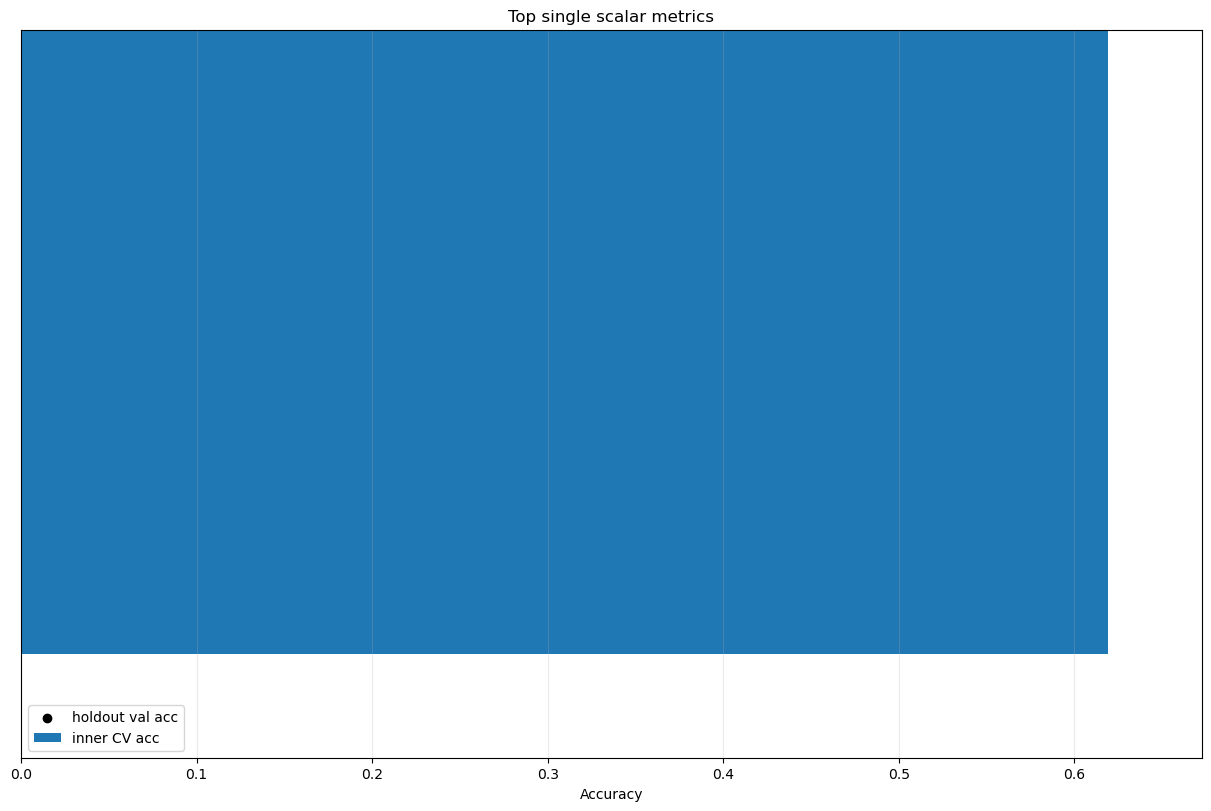

,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
1,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.634625,0.019948,0.675210,0.6370,0.6405,0.665342,1,0.039409
2,segmentig_delta_energy_importance_bins_top10_r...,single,segmentig_delta_energy_importance_bins_top10_r...,0.633650,0.022303,0.675360,0.6350,0.6340,0.658187,1,0.034399
3,segmentig_hand_rank_top10_delta_frac,single,segmentig_hand_rank_top10_delta_frac,0.632975,0.023132,0.673303,0.6375,0.6245,0.657759,1,0.102403
4,segmentig_hand_rank_top6_delta_frac,single,segmentig_hand_rank_top6_delta_frac,0.630850,0.023276,0.676915,0.6380,0.6330,0.663505,1,0.067462
...,...,...,...,...,...,...,...,...,...,...,...
199,segmentig_delta_energy_importance_binfrac_067,single,segmentig_delta_energy_importance_binfrac_067,0.495350,0.015256,0.492262,0.5210,0.5125,0.484872,-1,0.008001
200,segmentig_delta_energy_importance_binfrac_037,single,segmentig_delta_energy_importance_binfrac_037,0.495025,0.018475,0.503881,0.5170,0.4825,0.474330,1,0.008110
201,segmentig_delta_energy_importance_binfrac_058,single,segmentig_delta_energy_importance_binfrac_058,0.492800,0.016245,0.494344,0.5175,0.5255,0.473337,-1,0.008930
202,segmentig_delta_energy_importance_binfrac_022,single,segmentig_delta_energy_importance_binfrac_022,0.489200,0.018090,0.511557,0.5150,0.4935,0.485113,1,0.006201


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patch_success_analysis import bin_metrics

selection_random_state = 31
selection_examples_per_class = 1000
selection_cv_splits = 5
selection_cv_repeats = 20
force_handcrafted_selection_recompute = False

rows_df = pd.DataFrame(sf['rows'])
handcrafted_selection_result = bin_metrics.compute_or_load_handcrafted_selection(
    exp,
    rows_df,
    selection_random_state=selection_random_state,
    selection_examples_per_class=selection_examples_per_class,
    selection_cv_splits=selection_cv_splits,
    selection_cv_repeats=selection_cv_repeats,
    force=force_handcrafted_selection_recompute,
)
selection_df = handcrafted_selection_result['selection_df']
feature_cols = handcrafted_selection_result['feature_cols']
train_idx = handcrafted_selection_result['train_idx']
val_idx = handcrafted_selection_result['val_idx']
summary = handcrafted_selection_result['summary']

print(f"handcrafted selection cache: {handcrafted_selection_result['cache_path']}")
print(f"loaded_from_cache={handcrafted_selection_result['loaded_from_cache']}")
print(
    f"examples={summary['examples']}, features={summary['features']}, "
    f"train={summary['train']} ({summary['train_success']} success / {summary['train_fail']} fail), "
    f"val={summary['val']} ({summary['val_success']} success / {summary['val_fail']} fail)"
)
display(selection_df.head(30))
display(selection_df.sort_values(['val_acc', 'val_auc'], ascending=False).head(30))

if '_set_accuracy_ylim' not in globals():
    def _set_accuracy_ylim(ax, values, *, bottom_pad=0.025, top_pad=0.045):
        arr = np.asarray(values, dtype='float64').reshape(-1)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            ax.set_ylim(0.0, 1.0)
            return
        lo = float(arr.min())
        hi = float(arr.max())
        span = max(hi - lo, 0.02)
        lower = max(0.0, lo - max(float(bottom_pad), 0.15 * span))
        upper = min(1.0, hi + max(float(top_pad), 0.20 * span))
        if upper - lower < 0.08:
            extra = (0.08 - (upper - lower)) / 2.0
            lower = max(0.0, lower - extra)
            upper = min(1.0, upper + extra)
        ax.set_ylim(lower, upper)

single_best = selection_df.head(25).sort_values('cv_acc')
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.barh(single_best['name'], single_best['cv_acc'], label='inner CV acc')
ax.scatter(single_best['val_acc'], single_best['name'], color='black', zorder=3, label='holdout val acc')
_set_accuracy_ylim(ax, single_best[['cv_acc', 'val_acc']].to_numpy(), bottom_pad=0.03, top_pad=0.03)
ax.set_title('Top single scalar metrics')
ax.set_xlabel('Accuracy')
ax.grid(axis='x', alpha=0.25)
ax.legend()
plt.show()

# Keep the selected results in memory for follow-up cells.
selection_df

## Финальное сравнение: новые кандидаты против лучших предыдущих

В конце отдельно сравниваем три лучших одиночных handcrafted/scalar-кандидата с тремя лучшими метриками из предыдущего overall-сравнения. Ранжирование снова только по `val_acc`; `cv_acc` оставляем как диагностический признак, но не используем для порядка на графике.


,group,name,source,weights,train_acc,val_acc,val_auc,cv_acc
0,previous overall,segmentig_delta_energy_importance_bins_top10_l...,precomputed,,0.665,0.7000,0.746100,NaN
1,previous overall,0.1% top10 linear,manual_0.1%,"[1, 0.99, ..., 0.01]",0.665,0.6900,0.744300,NaN
2,previous overall,segmentig_delta_energy_importance_bins_top25_exp,precomputed,,0.665,0.6850,0.742600,NaN
3,final handcrafted,segmentig_align_top_jaccard,single,selected formula,0.637,0.6405,0.665342,0.634625
4,final handcrafted,segmentig_hand_overlap_top5_jaccard,single,selected formula,0.637,0.6405,0.665342,0.634625
5,final handcrafted,segmentig_hand_rank_ratio_top5_top25,single,selected formula,0.637,0.6395,0.664695,0.628175


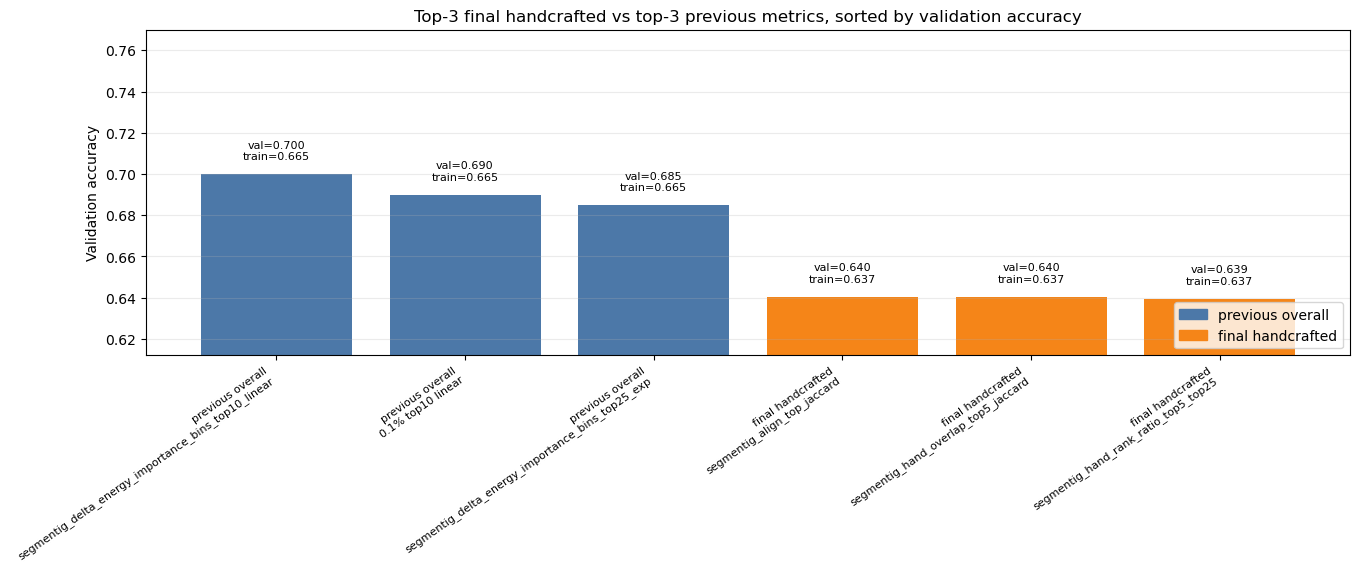

In [12]:
if 'overall_val_df' not in globals():
    raise RuntimeError('Сначала нужно выполнить блок с overall_val_df из секции про 1%/0.1%-бины.')
if 'selection_df' not in globals():
    raise RuntimeError('Сначала нужно выполнить Handcrafted feature selection, чтобы появился selection_df.')

previous_top3 = (
    overall_val_df.sort_values(['val_acc', 'val_auc'], ascending=False)
    .head(3)
    .assign(group='previous overall', cv_acc=np.nan)
    .rename(columns={'method': 'name'})
)
previous_top3 = previous_top3[['group', 'name', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc', 'cv_acc']]

new_top3 = (
    selection_df.sort_values(['val_acc', 'val_auc'], ascending=False)
    .head(3)
    .assign(group='final handcrafted', source=lambda d: d['family'], weights='selected formula')
    .rename(columns={'train_best_acc': 'train_acc'})
)
new_top3 = new_top3[['group', 'name', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc', 'cv_acc']]

top3_comparison_df = (
    pd.concat([previous_top3, new_top3], ignore_index=True)
    .sort_values(['val_acc', 'val_auc'], ascending=False)
    .reset_index(drop=True)
)
display(top3_comparison_df)

if '_set_accuracy_ylim' not in globals():
    def _set_accuracy_ylim(ax, values, *, bottom_pad=0.025, top_pad=0.045):
        arr = np.asarray(values, dtype='float64').reshape(-1)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            ax.set_ylim(0.0, 1.0)
            return
        lo = float(arr.min())
        hi = float(arr.max())
        span = max(hi - lo, 0.02)
        lower = max(0.0, lo - max(float(bottom_pad), 0.15 * span))
        upper = min(1.0, hi + max(float(top_pad), 0.20 * span))
        if upper - lower < 0.08:
            extra = (0.08 - (upper - lower)) / 2.0
            lower = max(0.0, lower - extra)
            upper = min(1.0, upper + extra)
        ax.set_ylim(lower, upper)

fig, ax = plt.subplots(figsize=(13.5, 5.6), constrained_layout=True)
x = np.arange(len(top3_comparison_df))
colors = top3_comparison_df['group'].map({
    'previous overall': '#4C78A8',
    'final handcrafted': '#F58518',
}).fillna('#9D755D').to_numpy()
bars = ax.bar(x, top3_comparison_df['val_acc'], color=colors)
for bar, val, train in zip(bars, top3_comparison_df['val_acc'], top3_comparison_df['train_acc']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.006,
        f'val={val:.3f}\ntrain={train:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )
labels = [
    f"{group}\n{str(name)[:58]}{'...' if len(str(name)) > 58 else ''}"
    for group, name in zip(top3_comparison_df['group'], top3_comparison_df['name'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
_set_accuracy_ylim(ax, top3_comparison_df[['train_acc', 'val_acc']].to_numpy(), top_pad=0.07)
ax.set_title('Top-3 final handcrafted vs top-3 previous metrics, sorted by validation accuracy')
ax.set_ylabel('Validation accuracy')
ax.grid(axis='y', alpha=0.25)
handles = [
    plt.Rectangle((0, 0), 1, 1, color='#4C78A8', label='previous overall'),
    plt.Rectangle((0, 0), 1, 1, color='#F58518', label='final handcrafted'),
]
ax.legend(handles=handles, loc='lower right')
plt.show()


## Unregularized logistic regression capacity

Проверяем верхнюю границу емкости bin-признаков: логистическая регрессия без регуляризации на 0.1% и 1% бинах для cutoff 1%, 5%, 10%, 25%, 50% и 100%. Threshold подбирается на train, точки показывают train/validation accuracy.

unregularized logreg capacity cache: new_experiments/outputs/patch_success_analysis/cache/binmetrics_unregularized_logreg_capacity_v1_5ba390d5ced7aaf5.pkl
loaded_from_cache=True


,granularity,cutoff_percent,n_bins,n_train,n_val,train_acc,val_acc,train_auc,val_auc,threshold,direction,coef_l2,n_iter,converged
0,0.1%,1.0,10,200,200,0.660,0.605,0.6941,0.6738,0.030773,1,1.031423,16,True
1,0.1%,5.0,50,200,200,0.750,0.625,0.8040,0.6366,-0.530767,1,2.681899,35,True
2,0.1%,10.0,100,200,200,1.000,0.600,1.0000,0.6640,-0.579321,1,876.121512,58,True
3,0.1%,25.0,250,200,200,1.000,0.620,1.0000,0.6722,-0.080924,1,22.488773,19,True
4,0.1%,50.0,500,200,200,1.000,0.655,1.0000,0.7080,-0.337127,1,13.445934,17,True
5,0.1%,100.0,1000,200,200,1.000,0.650,1.0000,0.7184,-0.262390,1,7.246958,15,True
6,1%,1.0,1,200,200,0.640,0.635,0.6522,0.7235,-0.139109,1,0.549643,4,True
7,1%,5.0,5,200,200,0.670,0.685,0.6914,0.7456,-0.011312,1,0.443685,13,True
8,1%,10.0,10,200,200,0.710,0.640,0.7071,0.7054,-0.011669,1,0.826734,14,True
9,1%,25.0,25,200,200,0.720,0.635,0.7843,0.6794,-0.146013,1,2.113817,27,True


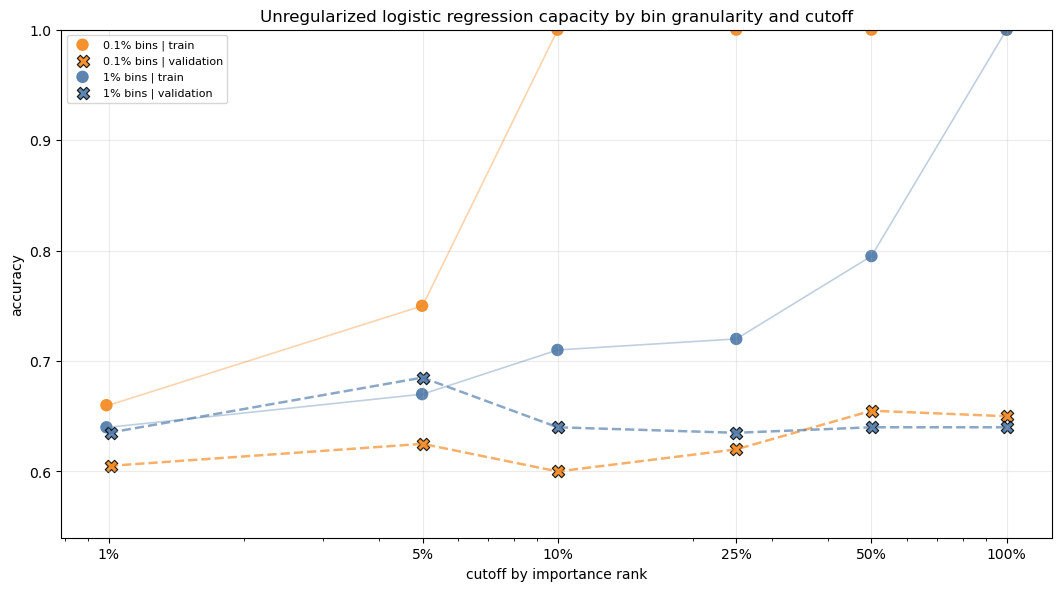

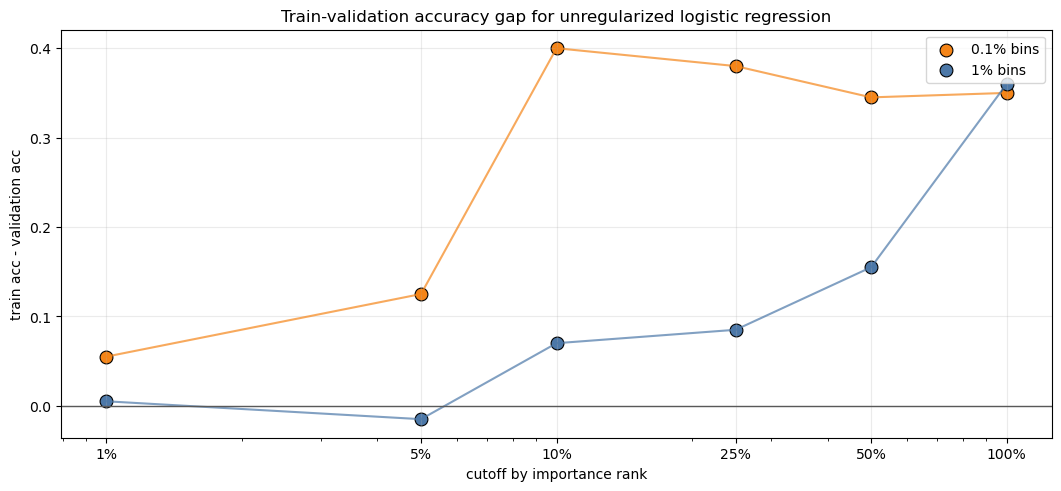

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from patch_success_analysis import bin_metrics

force_unregularized_logreg_capacity_recompute = False
unregularized_cutoffs = (1, 5, 10, 25, 50, 100)

unreg_capacity_result = bin_metrics.compute_or_load_unregularized_logreg_capacity(
    exp,
    rows_df,
    cutoffs=unregularized_cutoffs,
    granularities=("0.1%", "1%"),
    force=force_unregularized_logreg_capacity_recompute,
)
unreg_capacity_df = unreg_capacity_result["results_df"]

print(f"unregularized logreg capacity cache: {unreg_capacity_result['cache_path']}")
print(f"loaded_from_cache={unreg_capacity_result['loaded_from_cache']}")
display(unreg_capacity_df.sort_values(['granularity', 'cutoff_percent']))

fig, ax = plt.subplots(figsize=(10.5, 5.8), constrained_layout=True)
color_by_granularity = {"0.1%": "#F58518", "1%": "#4C78A8"}
marker_by_split = {"train_acc": "o", "val_acc": "X"}
offset_by_split = {"train_acc": -0.012, "val_acc": 0.012}
for granularity, sub in unreg_capacity_df.groupby('granularity', sort=False):
    sub = sub.sort_values('cutoff_percent')
    color = color_by_granularity.get(granularity, None)
    for metric, split_label in [("train_acc", "train"), ("val_acc", "validation")]:
        x = sub['cutoff_percent'].to_numpy(dtype='float64') + offset_by_split[metric]
        ax.scatter(
            x,
            sub[metric],
            s=80,
            marker=marker_by_split[metric],
            color=color,
            edgecolor='black' if metric == 'val_acc' else 'none',
            linewidth=0.8,
            label=f"{granularity} bins | {split_label}",
            alpha=0.9,
        )
    ax.plot(sub['cutoff_percent'], sub['train_acc'], color=color, alpha=0.35, linewidth=1.2)
    ax.plot(sub['cutoff_percent'], sub['val_acc'], color=color, alpha=0.65, linewidth=1.8, linestyle='--')

ax.set_xscale('log')
ax.set_xticks(list(unregularized_cutoffs))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda value, _pos: f'{value:g}%'))
if '_set_accuracy_ylim' in globals():
    _set_accuracy_ylim(ax, unreg_capacity_df[['train_acc', 'val_acc']].to_numpy(), bottom_pad=0.035, top_pad=0.055)
else:
    ax.set_ylim(0.0, 1.0)
ax.set_title('Unregularized logistic regression capacity by bin granularity and cutoff')
ax.set_xlabel('cutoff by importance rank')
ax.set_ylabel('accuracy')
ax.grid(axis='both', alpha=0.25)
ax.legend(loc='best', fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
for granularity, sub in unreg_capacity_df.groupby('granularity', sort=False):
    sub = sub.sort_values('cutoff_percent')
    color = color_by_granularity.get(granularity, None)
    gap = sub['train_acc'].to_numpy(dtype='float64') - sub['val_acc'].to_numpy(dtype='float64')
    ax.scatter(sub['cutoff_percent'], gap, s=85, color=color, edgecolor='black', linewidth=0.8, label=f"{granularity} bins")
    ax.plot(sub['cutoff_percent'], gap, color=color, alpha=0.7)
ax.axhline(0, color='0.35', linewidth=1)
ax.set_xscale('log')
ax.set_xticks(list(unregularized_cutoffs))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda value, _pos: f'{value:g}%'))
ax.set_title('Train-validation accuracy gap for unregularized logistic regression')
ax.set_xlabel('cutoff by importance rank')
ax.set_ylabel('train acc - validation acc')
ax.grid(axis='both', alpha=0.25)
ax.legend(loc='best')
plt.show()


## Robust product compression metrics

Пробуем смягчить доминирование нескольких гигантских компонент в `|importance| * |delta|`: логарифм только по importance с разной силой сжатия, power compression и trim product на 99% / 99.5%. Сравниваем варианты внутри top 3%, 5% и 10% нейронов по `|SegmentIG|`.

robust product compression cache: new_experiments/outputs/patch_success_analysis/cache/binmetrics_robust_product_compression_v1_8c04ffebc3013689.pkl
loaded_from_cache=False
skipped=0


,metric,roc_auc,best_accuracy,best_threshold,best_direction,family,top_percent
0,segmentig_delta_importance_product_top3_power_...,0.622857,0.594580,0.011438,1,power importance,3
1,segmentig_delta_importance_product_top5_power_...,0.618829,0.592809,0.013684,1,power importance,5
2,segmentig_delta_importance_product_top10_power...,0.617058,0.591392,0.014745,1,power importance,10
3,segmentig_delta_importance_product_top5_power_0p5,0.586831,0.567659,0.004603,1,power importance,5
4,segmentig_delta_importance_product_top3_power_0p5,0.589229,0.567304,0.003370,1,power importance,3
5,segmentig_delta_importance_product_top10_power...,0.586271,0.566773,0.004723,1,power importance,10
6,segmentig_delta_importance_product_top5_power_...,0.571643,0.555969,0.001162,1,power importance,5
7,segmentig_delta_importance_product_top10_power...,0.571478,0.555969,0.001179,1,power importance,10
8,segmentig_delta_importance_product_top3_power_...,0.572809,0.555615,0.001165,1,power importance,3
9,segmentig_delta_importance_product_top5_logbas...,0.566820,0.552958,0.001438,1,log importance,5


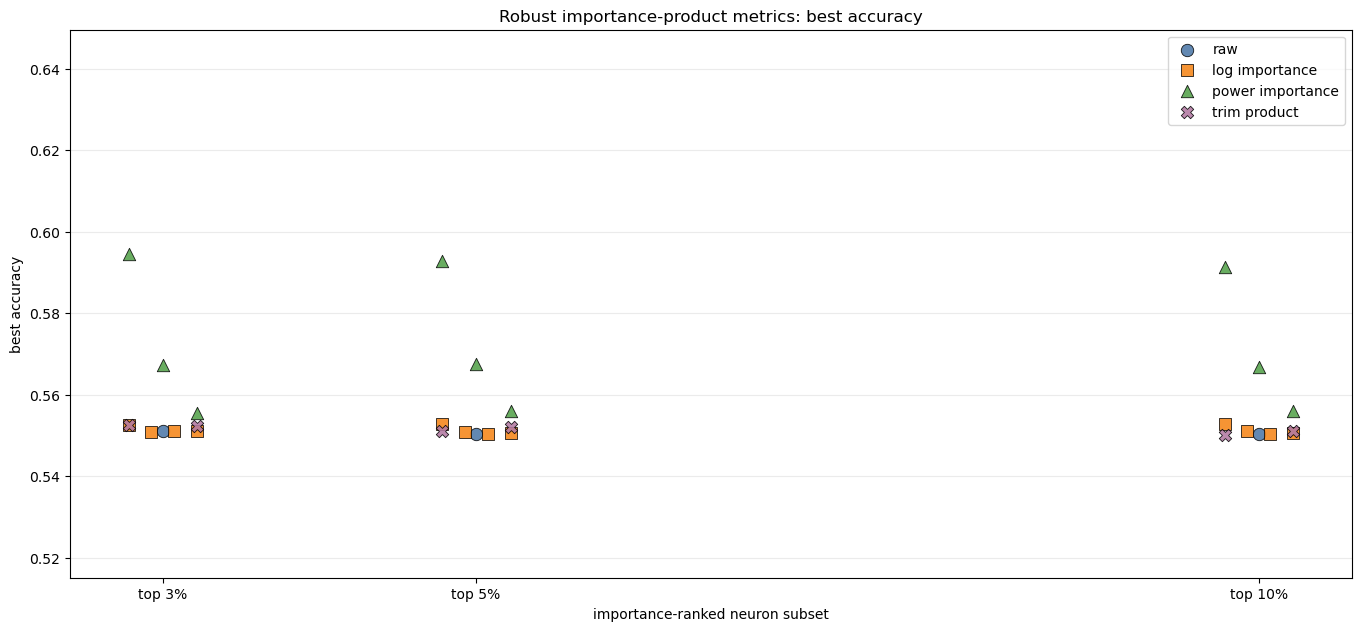

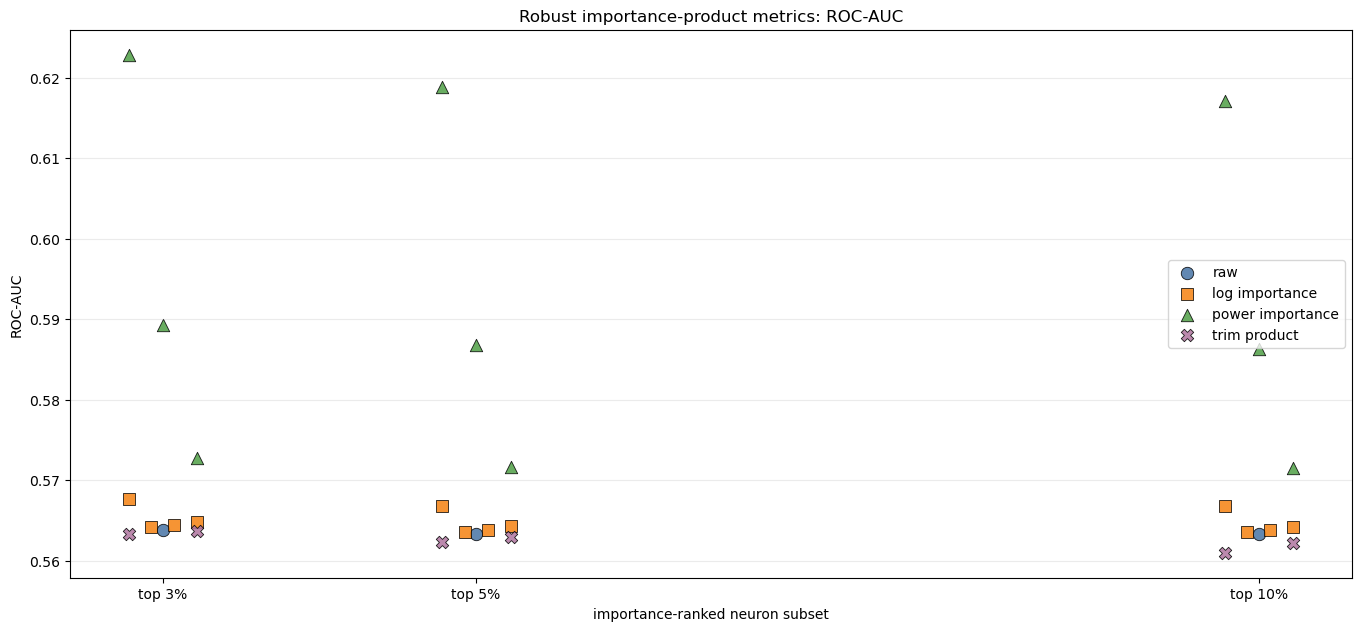

,metric,family,top_percent,roc_auc,best_accuracy,best_threshold,best_direction
0,segmentig_delta_importance_product_top3_power_...,power importance,3,0.622857,0.594580,0.011438,1
1,segmentig_delta_importance_product_top5_power_...,power importance,5,0.618829,0.592809,0.013684,1
2,segmentig_delta_importance_product_top10_power...,power importance,10,0.617058,0.591392,0.014745,1
3,segmentig_delta_importance_product_top5_power_0p5,power importance,5,0.586831,0.567659,0.004603,1
4,segmentig_delta_importance_product_top3_power_0p5,power importance,3,0.589229,0.567304,0.003370,1
5,segmentig_delta_importance_product_top10_power...,power importance,10,0.586271,0.566773,0.004723,1
6,segmentig_delta_importance_product_top5_power_...,power importance,5,0.571643,0.555969,0.001162,1
7,segmentig_delta_importance_product_top10_power...,power importance,10,0.571478,0.555969,0.001179,1
8,segmentig_delta_importance_product_top3_power_...,power importance,3,0.572809,0.555615,0.001165,1
9,segmentig_delta_importance_product_top5_logbas...,log importance,5,0.566820,0.552958,0.001438,1


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from patch_success_analysis import bin_metrics

force_robust_product_compression_recompute = False

robust_product_result = bin_metrics.compute_or_load_robust_product_compression_comparison(
    exp,
    rows_df,
    top_percents=(3, 5, 10),
    log_bases=(1.5, 2.0, np.e, 10.0),
    power_alphas=(0.25, 0.5, 0.75),
    trim_quantiles=(99.0, 99.5),
    force=force_robust_product_compression_recompute,
)
robust_product_quality = robust_product_result["quality_df"]

print(f"robust product compression cache: {robust_product_result['cache_path']}")
print(f"loaded_from_cache={robust_product_result['loaded_from_cache']}")
print(f"skipped={robust_product_result.get('n_skipped', 0)}")
display(robust_product_quality)

plot_df = robust_product_quality.copy()
plot_df["variant"] = (
    plot_df["metric"]
    .str.replace("segmentig_delta_importance_product_", "", regex=False)
    .str.replace("top", "top ", regex=False)
    .str.replace("_logbase_", " log base ", regex=False)
    .str.replace("_power_", " power ", regex=False)
    .str.replace("_trim_q", " trim q", regex=False)
    .str.replace("_raw", " raw", regex=False)
)

family_order = ["raw", "log importance", "power importance", "trim product"]
marker_by_family = {
    "raw": "o",
    "log importance": "s",
    "power importance": "^",
    "trim product": "X",
}
color_by_family = {
    "raw": "#4C78A8",
    "log importance": "#F58518",
    "power importance": "#54A24B",
    "trim product": "#B279A2",
}

fig, ax = plt.subplots(figsize=(13.5, 6.2), constrained_layout=True)
for family in family_order:
    sub = plot_df[plot_df["family"] == family].sort_values(["top_percent", "metric"])
    if sub.empty:
        continue
    x_base = sub["top_percent"].to_numpy(dtype="float64")
    offsets = np.linspace(-0.18, 0.18, max(1, len(sub.groupby("top_percent").head(1))))
    for top_percent, top_sub in sub.groupby("top_percent"):
        top_sub = top_sub.sort_values("metric").reset_index(drop=True)
        local_offsets = np.linspace(-0.22, 0.22, len(top_sub)) if len(top_sub) > 1 else np.array([0.0])
        ax.scatter(
            top_sub["top_percent"].to_numpy(dtype="float64") + local_offsets,
            top_sub["best_accuracy"],
            s=80,
            marker=marker_by_family.get(family, "o"),
            color=color_by_family.get(family),
            edgecolor="black",
            linewidth=0.6,
            alpha=0.88,
            label=family if top_percent == sub["top_percent"].min() else None,
        )

ax.set_xticks([3, 5, 10])
ax.set_xticklabels(["top 3%", "top 5%", "top 10%"])
if "_set_accuracy_ylim" in globals():
    _set_accuracy_ylim(ax, plot_df["best_accuracy"].to_numpy(), bottom_pad=0.035, top_pad=0.055)
else:
    ax.set_ylim(0.0, 1.0)
ax.set_title("Robust importance-product metrics: best accuracy")
ax.set_xlabel("importance-ranked neuron subset")
ax.set_ylabel("best accuracy")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(13.5, 6.2), constrained_layout=True)
for family in family_order:
    sub = plot_df[plot_df["family"] == family].sort_values(["top_percent", "metric"])
    if sub.empty:
        continue
    for top_percent, top_sub in sub.groupby("top_percent"):
        top_sub = top_sub.sort_values("metric").reset_index(drop=True)
        local_offsets = np.linspace(-0.22, 0.22, len(top_sub)) if len(top_sub) > 1 else np.array([0.0])
        ax.scatter(
            top_sub["top_percent"].to_numpy(dtype="float64") + local_offsets,
            top_sub["roc_auc"],
            s=80,
            marker=marker_by_family.get(family, "o"),
            color=color_by_family.get(family),
            edgecolor="black",
            linewidth=0.6,
            alpha=0.88,
            label=family if top_percent == sub["top_percent"].min() else None,
        )

ax.set_xticks([3, 5, 10])
ax.set_xticklabels(["top 3%", "top 5%", "top 10%"])
ax.set_title("Robust importance-product metrics: ROC-AUC")
ax.set_xlabel("importance-ranked neuron subset")
ax.set_ylabel("ROC-AUC")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="best")
plt.show()

display(
    robust_product_quality
    .sort_values(["best_accuracy", "roc_auc"], ascending=False)
    [["metric", "family", "top_percent", "roc_auc", "best_accuracy", "best_threshold", "best_direction"]]
    .head(30)
)